In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance


# CAPSTONE PROJECT

## Early Signal Emergence in Effort, Skill, and Mastery

## Project Overview

This project examines whether meaningful signals about student outcomes emerge before final course completion.

Using longitudinal assessment data, the project combines exploratory data analysis (EDA), prediction modeling, classification modeling, and intervention-oriented analysis to study how effort, skill, and mastery evolve throughout instruction.

The EDA section examines structural patterns in learning trajectories, while prediction and classification modeling evaluate how early those patterns become informative of later outcomes.

Together, these analyses explore descriptive, predictive, classification, and intervention-oriented perspectives on how instructional signals emerge over time.


## Exploratory Data Analysis (EDA)

This section examines aggregate structure in the data before predictive modeling.

The goal is to study patterns in first-attempt work, revisions, mastery growth, effort and skill relationships that may indicate how performance develops over instructional time.

In [2]:
##########################################
# Initialize EDA Data
##########################################

eda_df = pd.read_csv("student_totals_event_features_MERGED.csv")



##########################################
# EDA Parameters
##########################################

EDA_QUESTIONS_PER_STEP = 32

EDA_TOTAL_STEPS = 14



EDA_N_ASSIGNMENTS = 8


EDA_QUESTIONS_PER_ASSIGNMENT = 64



EDA_TOTAL_EXPECTED = EDA_TOTAL_STEPS * EDA_QUESTIONS_PER_STEP


EDA_TOTAL_AVAILABLE = EDA_N_ASSIGNMENTS * EDA_QUESTIONS_PER_ASSIGNMENT

EDA_MAX_EFFORT = EDA_TOTAL_AVAILABLE / EDA_TOTAL_EXPECTED


## Distribution of New Work

This analysis summarizes the distribution of first-attempt outcomes across all recorded assessment events.

The purpose is to establish a baseline view of how new work is distributed before considering revisions or cumulative mastery.

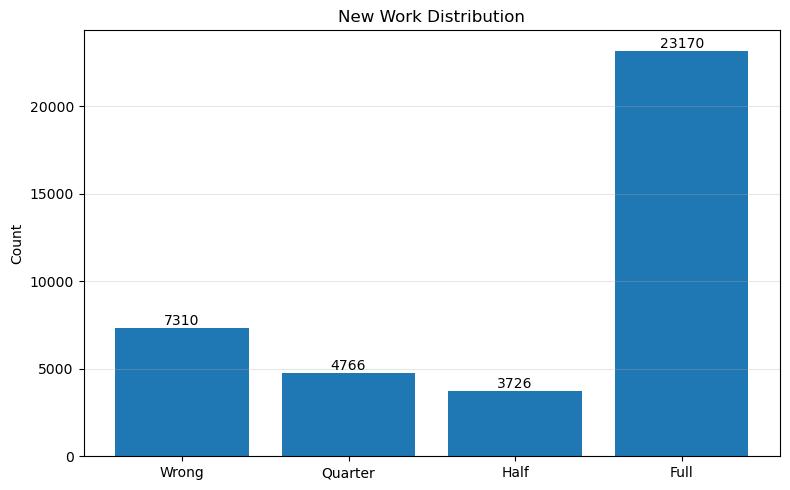

In [3]:
##########################################
##########################################
#
#      DISTRIBUTION OF NEW WORK
#
##########################################
##########################################




##########################################
# Calculate
##########################################


new_values = [
    eda_df["new_wrong"].sum(),
    eda_df["new_quarter"].sum(),
    eda_df["new_half"].sum(),
    eda_df["new_full"].sum()
]


new_labels = [
    "Wrong",
    "Quarter",
    "Half",
    "Full"
]



new_work_df = pd.DataFrame({
    "Outcome" : new_labels,
    "Count" : new_values
})






##########################################
# Plot
##########################################


fig, ax = plt.subplots(figsize = (8, 5))




bars = ax.bar(new_labels, new_values)

ax.bar_label(bars)


ax.set_title("New Work Distribution")
ax.set_ylabel("Count")

ax.grid(axis = "y", alpha = 0.3)

plt.tight_layout()



plt.savefig(
    "images/01_eda_new_work_distribution.png",
    dpi = 300,
    bbox_inches = "tight"
)


plt.show()




##########################################
# Audit
##########################################



#display(new_work_df)


## New Work Distribution Insights

New work outcomes are dominated by full-credit responses, with smaller proportions of partial-credit and incorrect outcomes.

This suggests that, at the aggregate level, successful first-attempt performance represents a substantial portion of activity.

At the same time, the presence of quarter and half credit outcomes indicates meaningful structured partial understanding rather than a simple correct/incorrect system.

## Distribution of Revisions

This analysis summarizes the frequency of corrections, regressions, and lateral revisions.

The purpose is to examine whether meaningful learning activity occurs through revision behavior, rather than first attempts alone.

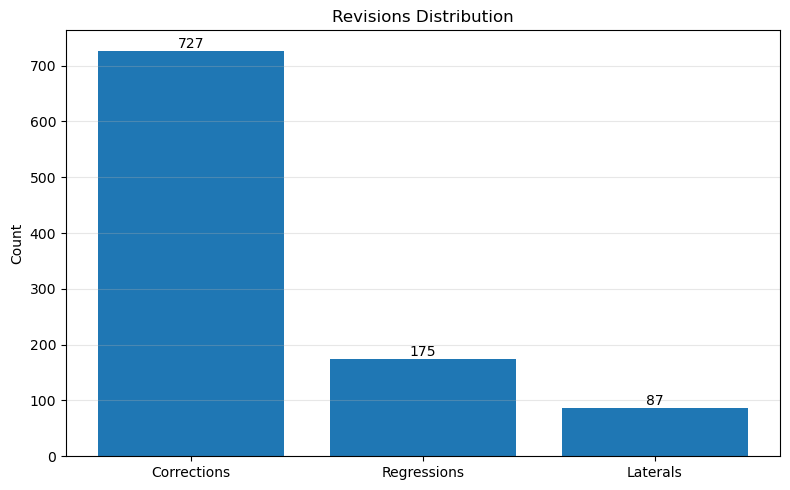

In [4]:
##########################################
##########################################
#
#     DISTRIBUTION OF REVISIONS
#
##########################################
##########################################



##########################################
# Calculate
##########################################


revision_values = [
    eda_df["total_corrections"].sum(),
    eda_df["total_regressions"].sum(),
    eda_df["total_laterals"].sum()
]


revision_labels = [
    "Corrections",
    "Regressions",
    "Laterals"
]


revisions_df = pd.DataFrame({
    "Revision Type" : revision_labels,
    "Count" : revision_values
})




##########################################
# Plot
##########################################


fig, ax = plt.subplots(figsize = (8, 5))




bars = ax.bar(revision_labels, revision_values)

ax.bar_label(bars)

ax.set_title("Revisions Distribution")
ax.set_ylabel("Count")

ax.grid(axis = "y", alpha = 0.3)


plt.tight_layout()



plt.savefig(
    "images/02_eda_revisions_distribution.png",
    dpi = 300,
    bbox_inches = "tight"
)



plt.show()



##########################################
# Audit
##########################################

#display(revisions_df)


## Revisions Distribution Insights

Revision activity is dominated by corrections, while regressions and lateral revisions occur less frequently.

This suggests that revision behavior more often reflects productive improvement than deterioration.

Taken together, the results support treating revisions as meaningful learning events rather than simply noise around first-attempt outcomes.

## Spread of Mastery

This analysis examines how the distribution of student mastery evolves over instructional time.

Median performance and interquartile spread are tracked to study both central tendency and dispersion.

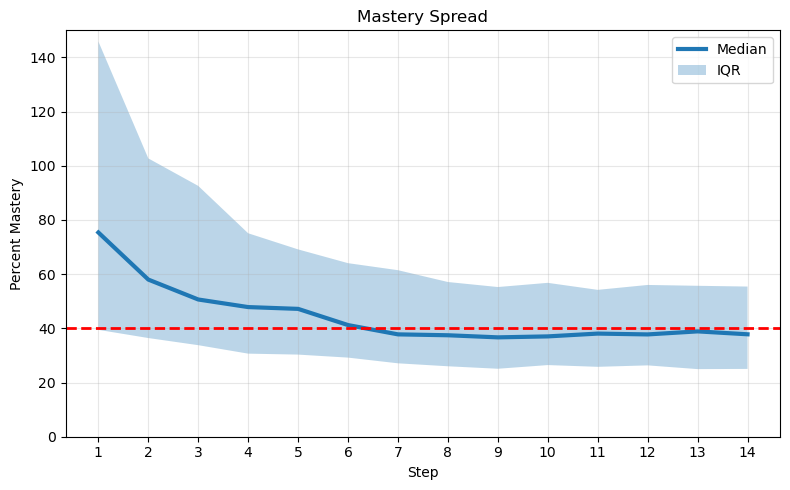

In [5]:
##########################################
##########################################
#
#          SPREAD OF MASTERY
#
##########################################
##########################################




##########################################
# Calculate
##########################################


spread_distribution_rows = []


for target_step in range(1, EDA_TOTAL_STEPS + 1):

    spread_cumulative_mastery = 0


    for step in range(1, target_step + 1):

        spread_cumulative_mastery += (
            eda_df[f"new_mastery_step_{step}"].fillna(0) +
            eda_df[f"corr_mastery_step_{step}"].fillna(0) +
            eda_df[f"reg_mastery_step_{step}"].fillna(0)
        )

    spread_mastery_percent = (
        spread_cumulative_mastery / (target_step * EDA_QUESTIONS_PER_STEP)
    ) * 100


    spread_distribution_rows.append({
        "Step" : target_step,
        "Median" : np.median(spread_mastery_percent),
        "Q1" : np.percentile(spread_mastery_percent, 25),
        "Q3" : np.percentile(spread_mastery_percent, 75)
    })

spread_distribution_df = pd.DataFrame(spread_distribution_rows)




##########################################
# Plot
##########################################

plt.figure(figsize = (8, 5))


plt.plot(
    spread_distribution_df["Step"],
    spread_distribution_df["Median"],
    linewidth = 3,
    label = "Median"
)


plt.fill_between(
    spread_distribution_df["Step"],
    spread_distribution_df["Q1"],
    spread_distribution_df["Q3"],
    alpha = 0.3,
    label = "IQR"
)

plt.axhline(
    40,
    color = "red",
    linestyle = "--",
    linewidth = 2
)


plt.xlabel("Step")
plt.ylabel("Percent Mastery")
plt.title("Mastery Spread")


plt.grid(alpha = 0.3)

plt.legend(loc = "upper right")

plt.ylim(0, 150)




plt.xticks(range(1, EDA_TOTAL_STEPS + 1))

plt.tight_layout()


plt.savefig(
    "images/03_eda_mastery_spread.png",
    dpi = 300,
    bbox_inches = "tight"
)


plt.show()



##########################################
# Audit
##########################################

#display(spread_distribution_df)



## Mastery Spread Insights

Median mastery approaches the 40% threshold near Step 7 (approximately halfway through the instructional sequence).

This suggests a possible midpoint transition in aggregate performance growth.

The persistent interquartile spread also indicates substantial heterogeneity in student trajectories, motivating later tiered analyses.

## Distribution of Mastery

This heatmap examines how students distribute across grade-band levels over time.

Rather than summarizing only averages, this view highlights how the broader mastery distribution shifts across instructional steps.

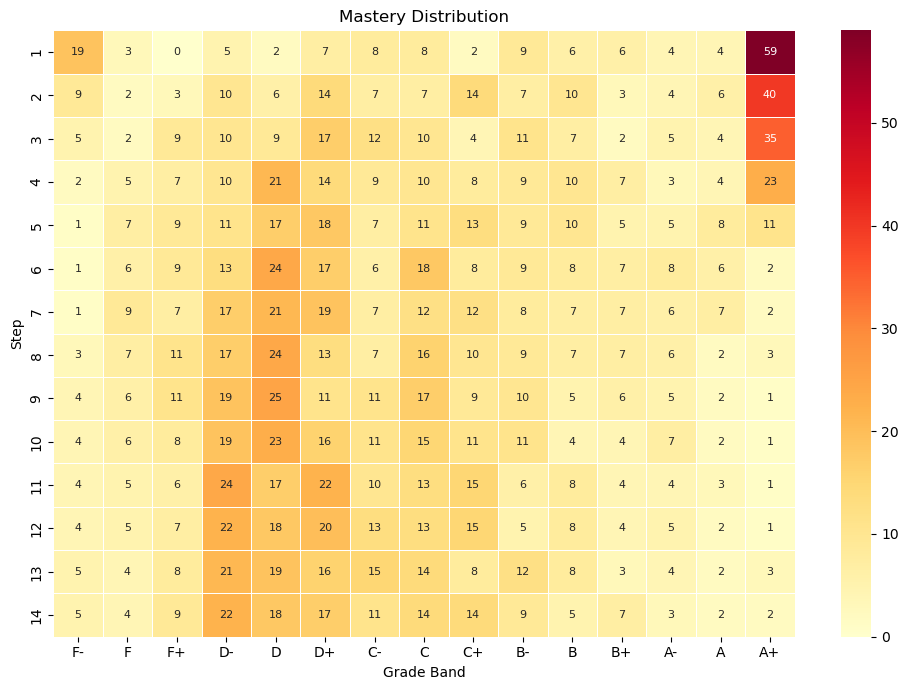

In [6]:
##########################################
##########################################
#
#      DISTRIBUTION OF MASTERY
#
##########################################
##########################################



##########################################
# Calculate
##########################################

heat_grade_band_bins = [
    -np.inf, 
    6.66, 13.32, 19.99,
    26.66, 33.32, 39.99,
    46.66, 53.32, 59.99,
    66.66, 73.32, 79.99,
    86.66, 93.32, np.inf
]


heat_grade_band_labels = [
    "F-", "F", "F+",
    "D-", "D", "D+",
    "C-", "C", "C+",
    "B-", "B", "B+",
    "A-", "A", "A+"
]



heat_grade_band_rows = []


for target_step in range(1, EDA_TOTAL_STEPS + 1):

    heat_cumulative_mastery = 0


    for step in range(1, target_step + 1):

        heat_cumulative_mastery += (
            eda_df[f"new_mastery_step_{step}"].fillna(0) +
            eda_df[f"corr_mastery_step_{step}"].fillna(0) +
            eda_df[f"reg_mastery_step_{step}"].fillna(0)
        )

    heat_mastery_percent = (
        heat_cumulative_mastery / (target_step * EDA_QUESTIONS_PER_STEP)
    ) * 100



    heat_grade_bands = pd.cut(
        heat_mastery_percent,
        bins = heat_grade_band_bins,
        labels = heat_grade_band_labels
    )


    heat_grade_band_counts = (
        heat_grade_bands
        .value_counts()
        .reindex(heat_grade_band_labels, fill_value = 0)
    )

    heat_grade_band_rows.append(heat_grade_band_counts)


heat_grade_band_df = pd.DataFrame(
    heat_grade_band_rows,
    index = range(1, EDA_TOTAL_STEPS + 1)
)




##########################################
# Plot
##########################################



plt.figure(figsize = (10, 7))


sns.heatmap(
    heat_grade_band_df,
    cmap = "YlOrRd",
    annot = True,
    fmt = "d",
    linewidths = 0.5,
    linecolor = "white",
    annot_kws = {"fontsize" : 8}
)





plt.title("Mastery Distribution")
plt.xlabel("Grade Band")
plt.ylabel("Step")


plt.tight_layout()



plt.savefig(
    "images/04_eda_mastery_distribution.png",
    dpi = 300,
    bbox_inches = "tight"
)


plt.show()

    
##########################################
# Audit
##########################################

#display(heat_grade_band_df)



## Mastery Distribution Insights

The mastery distribution begins to stabilize around Step 7, with broad structural patterns emerging well before the final steps.

Although individual movement continues, much of the distributional shape appears established by roughly halfway through the sequence.

This supports the broader theme that meaningful performance structure emerges earlier than final outcomes alone might suggest.

## Relationship of Effort and Skill

This analysis models student performance in a two-feature geometry defined by effort and skill.

Iso-grade contours provide a structural view of how these features combine to relate to overall performance.

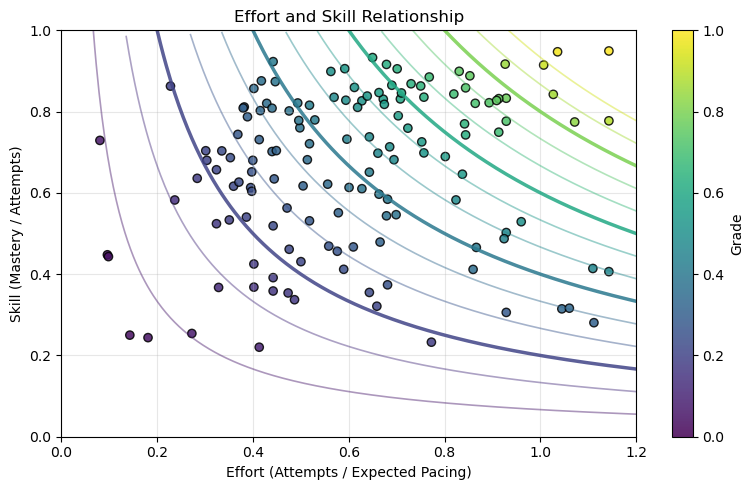

In [7]:
##########################################
##########################################
#
#     RELATIONSHIP OF EFFORT AND SKILL
#
##########################################
##########################################






##########################################
# Calculate
##########################################

effort_skill_records = []


for _, row in eda_df.iterrows():


    cumulative_attempts = 0
    cumulative_mastery = 0



    for step in range(1, EDA_TOTAL_STEPS + 1):


        new_attempt = row[f"new_attempts_step_{step}"]

        new_accuracy = row[f"new_accuracy_step_{step}"]


        if pd.isna(new_attempt):
            new_attempt = 0


        if pd.isna(new_accuracy):
            new_accuracy = 0



        cumulative_attempts += new_attempt

        cumulative_mastery += new_attempt * new_accuracy


    

    effort = cumulative_attempts / EDA_TOTAL_EXPECTED


    
    if cumulative_attempts > 0:
         skill = cumulative_mastery / cumulative_attempts
    else:
        skill = 0





    grade = min(
        cumulative_mastery / EDA_TOTAL_EXPECTED, 
        1
    )


    effort_skill_records.append(
        (effort, skill, grade)
    )


effort_skill_df = pd.DataFrame(
    effort_skill_records,
    columns = ["effort", "skill", "grade"]
)



##########################################
# Plot
##########################################




plt.figure(figsize = (8, 5))





effort_skill_scatter = plt.scatter(
    effort_skill_df["effort"],
    effort_skill_df["skill"],
    c = effort_skill_df["grade"],
    cmap = "viridis",
    vmin = 0,
    vmax = 1,
    edgecolor = "black",
    alpha = 0.85
)


iso_levels = np.array([
    0.0666, 0.1332, 0.1999,
    0.2666, 0.3332, 0.3999,
    0.4666, 0.5332, 0.5999,
    0.6666, 0.7332, 0.7999,
    0.8666, 0.9332
])


major_grade_levels = {
    0.1999, 0.3999, 0.5999, 0.7999
}


effort_values = np.linspace(
    0.01,
    EDA_MAX_EFFORT * 1.05,
    400     
)




for iso_level in iso_levels:

    iso_curve = iso_level / effort_values

    iso_curve[iso_curve > 1] = np.nan


    if iso_level in major_grade_levels:
        iso_line_width = 2.5
    else:
        iso_line_width = 1.2



    if iso_level in major_grade_levels:
        iso_alpha = 0.85
    else:
        iso_alpha = 0.45



    
    plt.plot(
        effort_values,
        iso_curve,
        color = plt.cm.viridis(iso_level),
        linewidth = iso_line_width,
        alpha = iso_alpha
    )






plt.xlim(0, EDA_MAX_EFFORT * 1.05)

plt.ylim(0, 1)


plt.xlabel("Effort (Attempts / Expected Pacing)")

plt.ylabel("Skill (Mastery / Attempts)")

plt.title("Effort and Skill Relationship")

plt.grid(alpha = 0.3)

plt.colorbar(
    effort_skill_scatter,
    label = "Grade"
)

    


plt.tight_layout()



plt.savefig(
    "images/05_eda_effort_skill_relationship.png",
    dpi = 300,
    bbox_inches = "tight"
)


plt.show()




## Effort and Skill Relationship Insights

This framework is based on new-work behavior only and does not incorporate revision events.

An important implication is that similar final outcomes may arise through different effort-skill combinations.

For example, a student with moderate effort and high skill may achieve outcomes similar to a student with higher effort but lower skill.

This suggests final performance may conceal multiple underlying pathways.

The iso-grade contours also reveal a geometric asymmetry:

Lower grade bands occupy comparatively large regions of the effort-skill space, while high-grade bands occupy much smaller regions despite representing equal percentage-width intervals.

This reflects the increasing joint demands required to sustain higher levels of performance.

## EDA Summary

Across the exploratory analyses, several patterns emerge:

- First-attempt outcomes are dominated by full credit, while revisions are primarily corrective.

- Aggregate mastery structure begins to stabilize around Step 7, suggesting an approximate halfway point where performance trajectories become more established.

- Effort and skill define multiple pathways to similar final outcomes, indicating that comparable grades may emerge from different behavioral patterns.

Together, these findings motivate predictive modeling as a natural next step for evaluating when meaningful signal becomes detectable.

## Prediction Modeling

This section evaluates whether the structural patterns observed in EDA translate into measurable predictive signal over instructional time.

Regression modeling is used to study prediction error, explanatory power, feature influence, and differences in signal emergence across performance tiers.

In [8]:
##########################################
##########################################
#
#     PREDICTION HELPER FUNCTIONS
#
##########################################
##########################################




##########################################
# Global Parameters
##########################################


QUESTIONS_PER_STEP = 32





def initialize(filepath):


    ##########################################
    # Read File
    ##########################################
    df = pd.read_csv(filepath)


    ##########################################
    # Find Step Columns
    ##########################################

    
    step_columns = []

    for column in df.columns:

        if "new_attempts_step_" in column:

            step_columns.append(column)


    ##########################################
    # Extract Step Numbers
    ##########################################

        
    step_numbers = []

    for column in step_columns:

        step_num = int(
            column.split("_")[-1]
        )

        step_numbers.append(
            step_num
        )


    ##########################################
    # Maximum Step
    ##########################################
    
    max_step = max(
        step_numbers
    )

    return df, max_step









def build_target_continuous(df, max_step):

    ##########################################
    # Calculate Final Mastery
    ##########################################
    

    final_mastery = (

        0.25 * df["final_quarter"] +
        0.50 * df["final_half"] +
        1.00 * df["final_full"]
    )


    ##########################################
    # Calculate Final Expectation
    ##########################################    

    final_expectation = (
        max_step * QUESTIONS_PER_STEP
    )



    ##########################################
    # Build Continuous Target
    ##########################################   
    
    y = (
        final_mastery / final_expectation
    )


    y = y.fillna(0)

    

    return y

    




def build_split_continuous(df, y):


    ##########################################
    # Train-Test Split
    ##########################################   
    
    df_train, df_test, y_train, y_test = train_test_split(

        df, 
        y, 
        test_size = 0.2,
        random_state = 42
    )

    return df_train, df_test, y_train, y_test









def build_features(df, step):


    ##########################################
    # Calculate Cumulative Attempts
    ##########################################   
    
    attempts = 0

    for i in range(1, step + 1):

        attempts += (
            df[f"new_attempts_step_{i}"]
        )
    


    ##########################################
    # Calculate Cumulative Mastery
    ##########################################   
    
    mastery = 0

    for i in range(1, step + 1):

        mastery += (
            df[f"new_attempts_step_{i}"] *
            df[f"new_accuracy_step_{i}"].fillna(0)
        )
            




    ##########################################
    # Calculate Effort 
    ##########################################   
    
    effort = (
        attempts / (step * QUESTIONS_PER_STEP)
    )


    ##########################################
    # Calculate Skill 
    ##########################################   

    
    skill = (
            mastery / attempts.replace(0, np.nan)
        ).fillna(0)



    ##########################################
    # Return Features
    ##########################################   
    
    return pd.DataFrame({
        "effort" : effort,
        "skill" : skill
    })



## Ridge Model Selection

This analysis uses cross-validated ridge regression with polynomial features to study bias-variance tradeoffs and identify a stable predictive model.

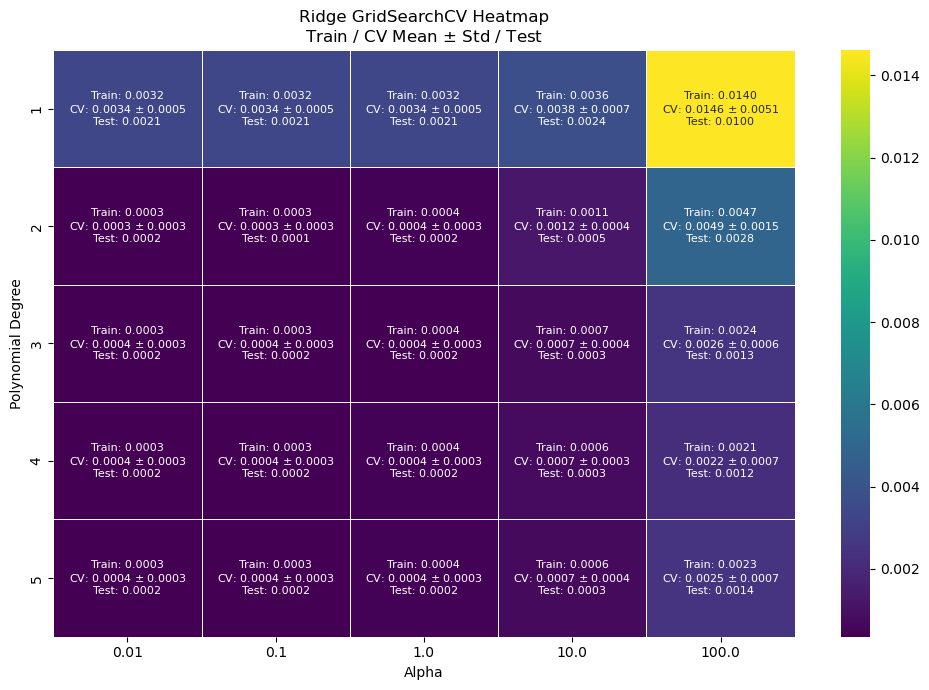


Best Parameters
{'polynomial_features__degree': 2, 'ridge__alpha': 0.01}


In [9]:
##########################################
##########################################
#
#          RIDGE REGRESSION
#
#        GRIDSEARCHCV HEATMAP
#
#            CALCULATION
#
##########################################
##########################################





##########################################
# Parameters
##########################################


degrees = [1, 2, 3, 4, 5]

alphas = [0.01, 0.1, 1, 10, 100]


##########################################
# Initialize
##########################################

df, max_step = initialize("student_totals_event_features_MERGED.csv")


##########################################
# Target
##########################################

y = build_target_continuous(df, max_step)



##########################################
# Split
##########################################

df_train, df_test, y_train, y_test = build_split_continuous(df, y)



##########################################
# Features
##########################################

X_train = build_features(df_train, max_step)


X_test = build_features(df_test, max_step)




##########################################
# Pipeline
##########################################


lin_reg_grid_pipeline = Pipeline([
    ("polynomial_features", PolynomialFeatures(
        include_bias = False
    )),
    ("standard_scaler", StandardScaler()),
    ("ridge", Ridge())
])




##########################################
# Parameter Grid
##########################################

param_grid = {
    "polynomial_features__degree" : degrees,
    "ridge__alpha" : alphas
}


##########################################
# Grid Search
##########################################


lin_reg_grid_search = GridSearchCV(
    estimator = lin_reg_grid_pipeline,
    param_grid = param_grid,
    scoring = "neg_mean_squared_error",
    cv = 5,
    return_train_score = True
)



lin_reg_grid_search.fit(X_train, y_train)



##########################################
# Save Results
##########################################

ridge_heat_df = pd.DataFrame(
    lin_reg_grid_search.cv_results_
)



ridge_heat_df["Train MSE"] = -ridge_heat_df["mean_train_score"]


ridge_heat_df["CV MSE"] = -ridge_heat_df["mean_test_score"]


ridge_heat_df["CV Std"] = ridge_heat_df["std_test_score"]





##########################################
# Calculate Grid Test MSE
##########################################


ridge_test_mse_list = []


for _, row in ridge_heat_df.iterrows():

    degree = row["param_polynomial_features__degree"]

    alpha = row["param_ridge__alpha"]


    lin_reg_grid_model = Pipeline([
        ("polynomial_features", PolynomialFeatures(
            degree = degree,
            include_bias = False
        )),
        ("standard_scaler", StandardScaler()),
        ("ridge", Ridge(
            alpha = alpha
        ))
    ])

    lin_reg_grid_model.fit(X_train, y_train)

    grid_test_preds = lin_reg_grid_model.predict(X_test)

    test_mse = mean_squared_error(
        y_test,
        grid_test_preds
    )

    ridge_test_mse_list.append(
        test_mse
    )






ridge_heat_df["Test MSE"] = ridge_test_mse_list






##########################################
##########################################
#
#          RIDGE REGRESSION
#
#        GRIDSEARCHCV HEATMAP
#
#               PLOT
#
##########################################
##########################################


##########################################
# Create Heatmap Labels
##########################################


ridge_heat_df["label"] = ridge_heat_df.apply(
    lambda row: (
        f"Train: {row['Train MSE']:.4f}\n"
        f"CV: {row['CV MSE']:.4f} $\pm$ {row['CV Std']:.4f}\n"
        f"Test: {row['Test MSE']:.4f}"
    ),
    axis = 1
)




##########################################
# Pivot Tables
##########################################


ridge_mean_table = ridge_heat_df.pivot(
    index = "param_polynomial_features__degree",
    columns = "param_ridge__alpha",
    values = "CV MSE"
)


ridge_label_table = ridge_heat_df.pivot(
    index = "param_polynomial_features__degree",
    columns = "param_ridge__alpha",
    values = "label"
)



##########################################
# Heatmap
##########################################



plt.figure(figsize = (10, 7))


sns.heatmap(
    ridge_mean_table,
    annot = ridge_label_table,
    fmt = "",
    cmap = "viridis",
    linewidths = 0.5,
    linecolor = "white",
    annot_kws = {"fontsize" : 8}
)



plt.title(
    "Ridge GridSearchCV Heatmap\n"
    "Train / CV Mean $\pm$ Std / Test"
)


plt.xlabel("Alpha")
plt.ylabel("Polynomial Degree")



plt.tight_layout()



plt.savefig(
    "images/11_prediction_ridge_gridsearchcv_heatmap.png",
    dpi = 300,
    bbox_inches = "tight"
)


plt.show()







##########################################
# Audit 
##########################################


#display(
#    ridge_heat_df
#    .set_index(
#        [
#            "param_polynomial_features__degree",
#            "param_ridge__alpha"
#        ]
#    )
#    [
#        [
#            "Train MSE", 
#            "CV MSE",
#            "CV Std",
#            "Test MSE"
#        ]
#    ]
#    .sort_values(
#        by = "CV MSE"
#    )
#)


print("\nBest Parameters")
print(lin_reg_grid_search.best_params_)








## Ridge Model Selection Insights

The GridSearchCV heatmap suggests that moderate regularization with low-degree polynomial features provides the strongest balance of fit and stability.

At degree = 2, alpha = 0.01 and alpha = 0.1 produced essentially equivalent cross-validation performance, with alpha = 0.01 selected by GridSearchCV.

Because alpha = 0.1 provided comparable performance while using slightly stronger regularization, it was chosen as a near-optimal but slightly more stable model.

Higher-degree models produced diminishing gains and greater variability, suggesting additional complexity was not necessary.

## Global Prediction Diagnostics

This analysis evaluates global fit through predicted-versus-actual and residual diagnostics.

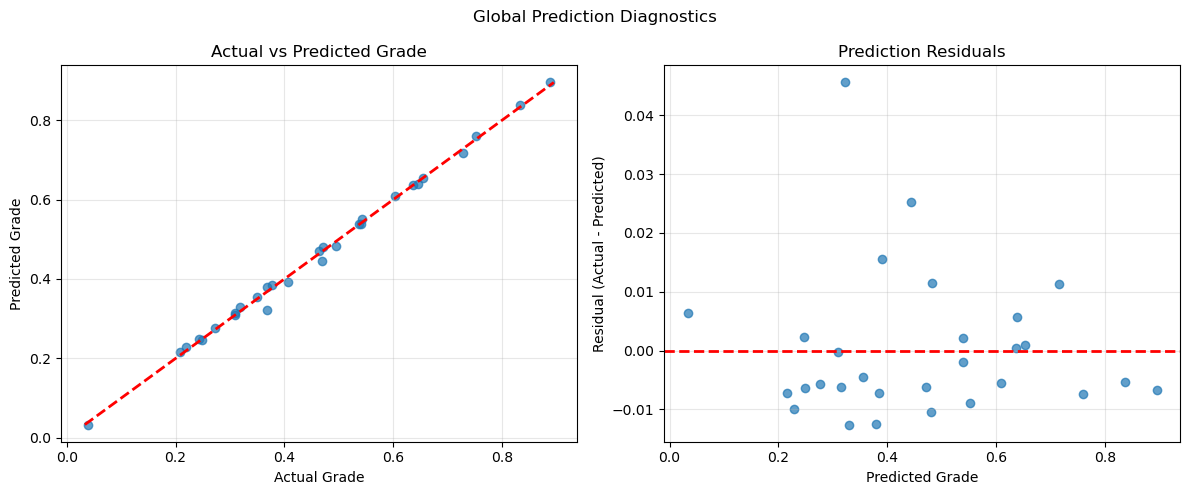

In [10]:
##########################################
##########################################
#
#       GLOBAL RIDGE REGRESSION
#     FIT AND RESIDUAL DIAGNOSTICS
#
#        POLYNOMIAL DEGREE = 2
#           ALPHA = 0.1
#
#            CALCULATION
#
##########################################
##########################################







##########################################
# Parameters
##########################################



degree = 2

alpha = 0.1



##########################################
# Initialize
##########################################

df, max_step = initialize("student_totals_event_features_MERGED.csv")


##########################################
# Target
##########################################

y = build_target_continuous(df, max_step)



##########################################
# Split
##########################################

df_train, df_test, y_train, y_test = build_split_continuous(df, y)



##########################################
# Features
##########################################

X_train = build_features(df_train, max_step)


X_test = build_features(df_test, max_step)






##########################################
# Model
##########################################

lin_reg_global_pipeline = Pipeline([
    ("polynomial_features", PolynomialFeatures(
        degree = degree,
        include_bias = False
    )),
    ("standard_scaler", StandardScaler()),
    ("ridge", Ridge(alpha = alpha))
])


lin_reg_global_pipeline.fit(X_train, y_train)




##########################################
# Calculate MSE
##########################################


train_preds = lin_reg_global_pipeline.predict(X_train)

test_preds = lin_reg_global_pipeline.predict(X_test)


train_mse = mean_squared_error(
    y_train,
    train_preds
)



test_mse = mean_squared_error(
    y_test,
    test_preds
)


global_residuals = y_test - test_preds




##########################################
# Save Results
##########################################


lin_reg_global_results_df = pd.DataFrame({
    "Global Actual Grade" : y_test,
    "Global Predicted Grade" : test_preds,
    "Global Residuals" : global_residuals,
})




##########################################
# Save Audit Results
##########################################


lin_reg_global_audit_df = pd.DataFrame({
    "Metric" : [
        "Train MSE",
        "Test MSE"
    ],
    "Value" : [
        train_mse, 
        test_mse
    ]
})








##########################################
##########################################
#
#       GLOBAL RIDGE REGRESSION
#     FIT AND RESIDUAL DIAGNOSTICS
#
#        POLYNOMIAL DEGREE = 2
#           ALPHA = 0.1
#
#            PLOT
#
##########################################
##########################################



##########################################
# Load Results
##########################################

lin_reg_global_preds = lin_reg_global_results_df["Global Predicted Grade"]

lin_reg_global_actual = lin_reg_global_results_df["Global Actual Grade"]

lin_reg_global_residuals = lin_reg_global_results_df["Global Residuals"]






fig, axes = plt.subplots(1, 2, figsize = (12, 5))




##########################################
# Actual vs Predicted
##########################################



ax = axes[0]

ax.scatter(lin_reg_global_actual, lin_reg_global_preds, alpha = 0.7)


min_val = min(lin_reg_global_preds.min(), lin_reg_global_actual.min())

max_val = max(lin_reg_global_preds.max(), lin_reg_global_actual.max())





ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    color = "red",
    linestyle = "--",
    linewidth = 2
)


ax.set_title("Actual vs Predicted Grade")
ax.set_xlabel("Actual Grade")
ax.set_ylabel("Predicted Grade")
ax.grid(alpha = 0.3)





##########################################
# Prediction Residuals
##########################################


ax = axes[1]


ax.scatter(lin_reg_global_preds, lin_reg_global_residuals, alpha = 0.7)




ax.axhline(
    0,
    color = "red",
    linestyle = "--",
    linewidth = 2
)



ax.set_title("Prediction Residuals")
ax.set_xlabel("Predicted Grade")
ax.set_ylabel("Residual (Actual - Predicted)")
ax.grid(alpha = 0.3)


plt.suptitle(
    "Global Prediction Diagnostics"
)


plt.tight_layout()


plt.savefig(
    "images/12_prediction_global_diagnostics.png",
    dpi = 300,
    bbox_inches = "tight"
)



plt.show()




##########################################
# Audit
##########################################





#display(
#    lin_reg_global_audit_df
#    .set_index("Metric")
#    [
#        [
#            "Value"
#        ]
#    ]
#)






## Global Prediction Diagnostics Insights

Predicted and actual grades align closely, suggesting the model captures substantial structure in the outcome.

Residuals show limited systematic pattern, supporting model adequacy across much of the response range.

Taken together, these diagnostics support using the selected ridge model for stepwise analyses.

## Stepwise Prediction Performance (MSE)

This analysis evaluates how prediction error changes as additional instructional information becomes available over time.

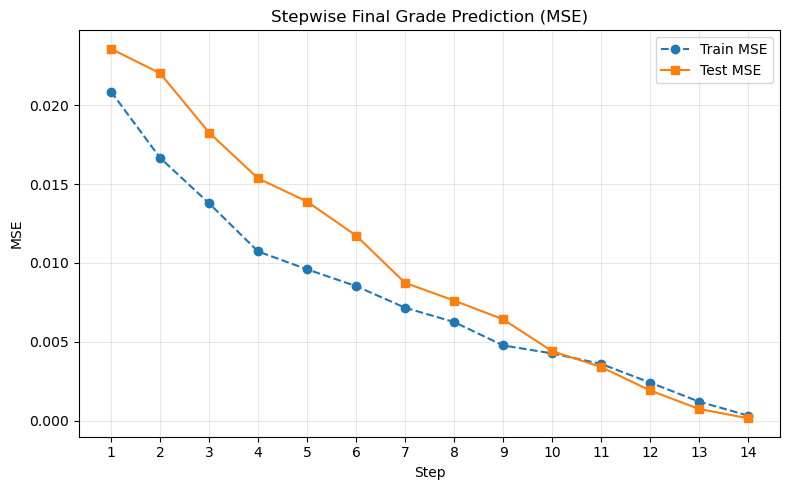

In [11]:
##########################################
##########################################
#
#       GLOBAL RIDGE REGRESSION
#      STEPWISE MODEL PERFORMANCE 
#               (MSE)
#
#        POLYNOMIAL DEGREE = 2
#           ALPHA = 0.1
#
#            CALCULATION
#
##########################################
##########################################







##########################################
# Parameters
##########################################



degree = 2

alpha = 0.1



##########################################
# Initialize
##########################################

df, max_step = initialize("student_totals_event_features_MERGED.csv")


##########################################
# Target
##########################################

y = build_target_continuous(df, max_step)



##########################################
# Split
##########################################

df_train, df_test, y_train, y_test = build_split_continuous(df, y)







##########################################
# Storage
##########################################

lin_reg_step_mse_results_list = []





##########################################
# Step Loop
##########################################

for step in range(1, max_step + 1):


    ##########################################
    # Features
    ##########################################

    
    X_train = build_features(df_train, step)

    X_test = build_features(df_test, step)


    ##########################################
    # Model
    ##########################################


    lin_reg_step_mse_model = Pipeline([
        ("polynomial_features", PolynomialFeatures(
            degree = degree,
            include_bias = False
        )),
        ("standard_scaler", StandardScaler()),
        ("ridge", Ridge(
            alpha = alpha
        ))
    ])


    lin_reg_step_mse_model.fit(X_train, y_train)





    
    ##########################################
    # Calculate MSE
    ##########################################


    train_preds = lin_reg_step_mse_model.predict(X_train)

    test_preds = lin_reg_step_mse_model.predict(X_test)


    train_mse = mean_squared_error(y_train, train_preds)

    test_mse = mean_squared_error(y_test, test_preds)


    ##########################################
    # Store Results
    ##########################################
    


    lin_reg_step_mse_results_list.append({
        "Step" : step,
        "Train MSE" : train_mse,
        "Test MSE" : test_mse
    })




##########################################
# Save Results
##########################################

lin_reg_step_mse_df = pd.DataFrame(lin_reg_step_mse_results_list)




##########################################
##########################################
#
#       GLOBAL RIDGE REGRESSION
#      STEPWISE MODEL PERFORMANCE 
#               (MSE)
#
#        POLYNOMIAL DEGREE = 2
#           ALPHA = 0.1
#
#               PLOT
#
##########################################
##########################################





plt.figure(figsize = (8, 5))


##########################################
# Plot Stepwise MSE
##########################################


plt.plot(
    lin_reg_step_mse_df["Step"],
    lin_reg_step_mse_df["Train MSE"],
    linestyle = "--",
    marker = "o",
    label = "Train MSE"
)




plt.plot(
    lin_reg_step_mse_df["Step"],
    lin_reg_step_mse_df["Test MSE"],
    linestyle = "-",
    marker = "s",
    label = "Test MSE"
)



##########################################
# Labels
##########################################

plt.xlabel("Step")

plt.ylabel("MSE")

plt.title(
    "Stepwise Final Grade Prediction (MSE)"
)

    
plt.xticks(range(1, max_step + 1))






##########################################
# Final Plot Formatting
##########################################


plt.legend(loc = "upper right")

plt.grid(alpha = 0.3)




plt.tight_layout()


plt.savefig(
    "images/13_prediction_stepwise_mse.png",
    dpi = 300,
    bbox_inches = "tight"
)



plt.show()



##########################################
# Audit
##########################################

#display(
#    lin_reg_step_mse_df
#    .set_index("Step")
#    [
#        [
#            "Train MSE",
#            "Test MSE"
#        ]
#    ]
#)






## Stepwise Prediction Performance Insights (MSE)

Prediction error decreases steadily across instructional steps.

Substantial improvement occurs during the middle portion of the sequence, with error continuing to decline through later steps.

By approximately Step 7 (halfway through instruction), test MSE decreases to approximately 0.0087, corresponding to an average prediction error of roughly 9% of final grade after converting MSE to RMSE.

By Step 10, test MSE decreases to approximately 0.0044 (approximately 6.6% average prediction error).

By the final instructional step, test MSE approaches zero, indicating cumulative effort and skill information provides highly accurate estimates of final outcomes.

## Stepwise Prediction Performance (R$^2$)

This analysis examines how predictive signal develops over instructional time.

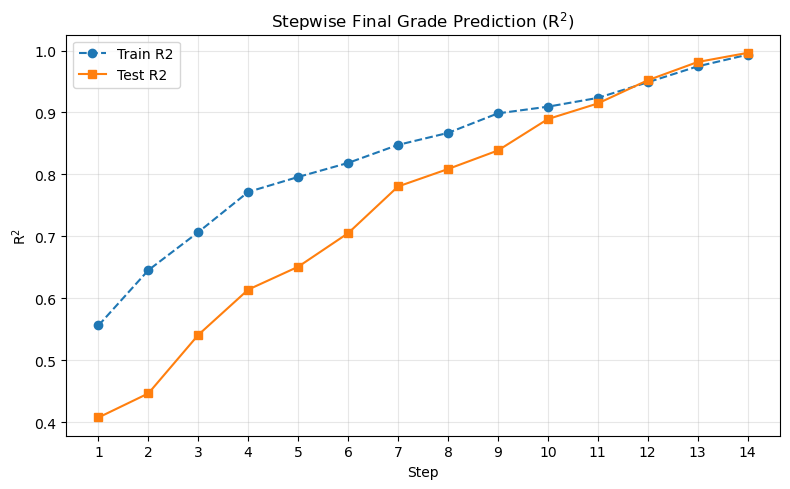

In [12]:
##########################################
##########################################
#
#       GLOBAL RIDGE REGRESSION
#      STEPWISE MODEL PERFORMANCE 
#               (R2)
#
#        POLYNOMIAL DEGREE = 2
#           ALPHA = 0.1
#
#            CALCULATION
#
##########################################
##########################################







##########################################
# Parameters
##########################################



degree = 2

alpha = 0.1



##########################################
# Initialize
##########################################

df, max_step = initialize("student_totals_event_features_MERGED.csv")


##########################################
# Target
##########################################

y = build_target_continuous(df, max_step)



##########################################
# Split
##########################################

df_train, df_test, y_train, y_test = build_split_continuous(df, y)







##########################################
# Storage
##########################################

lin_reg_step_r2_results_list = []





##########################################
# Step Loop
##########################################

for step in range(1, max_step + 1):


    ##########################################
    # Features
    ##########################################

    
    X_train = build_features(df_train, step)

    X_test = build_features(df_test, step)


    ##########################################
    # Model
    ##########################################


    lin_reg_step_r2_model = Pipeline([
        ("polynomial_features", PolynomialFeatures(
            degree = degree,
            include_bias = False
        )),
        ("standard_scaler", StandardScaler()),
        ("ridge", Ridge(
            alpha = alpha
        ))
    ])


    lin_reg_step_r2_model.fit(X_train, y_train)





    
    ##########################################
    # Calculate R2
    ##########################################


    train_preds = lin_reg_step_r2_model.predict(X_train)

    test_preds = lin_reg_step_r2_model.predict(X_test)


    train_r2 = r2_score(y_train, train_preds)

    test_r2 = r2_score(y_test, test_preds)


    ##########################################
    # Store Results
    ##########################################
    


    lin_reg_step_r2_results_list.append({
        "Step" : step,
        "Train R2" : train_r2,
        "Test R2" : test_r2
    })




##########################################
# Save Results
##########################################

lin_reg_step_r2_df = pd.DataFrame(lin_reg_step_r2_results_list)




##########################################
##########################################
#
#       GLOBAL RIDGE REGRESSION
#      STEPWISE MODEL PERFORMANCE 
#               (R2)
#
#        POLYNOMIAL DEGREE = 2
#           ALPHA = 0.1
#
#               PLOT
#
##########################################
##########################################





plt.figure(figsize = (8, 5))


##########################################
# Plot Stepwise R2
##########################################


plt.plot(
    lin_reg_step_r2_df["Step"],
    lin_reg_step_r2_df["Train R2"],
    linestyle = "--",
    marker = "o",
    label = "Train R2"
)




plt.plot(
    lin_reg_step_r2_df["Step"],
    lin_reg_step_r2_df["Test R2"],
    linestyle = "-",
    marker = "s",
    label = "Test R2"
)



##########################################
# Labels
##########################################

plt.xlabel("Step")

plt.ylabel("R$^2$")

plt.title(
    "Stepwise Final Grade Prediction (R$^2$)"
)

    
plt.xticks(range(1, max_step + 1))






##########################################
# Final Plot Formatting
##########################################


plt.legend(loc = "upper left")


plt.grid(alpha = 0.3)




plt.tight_layout()


plt.savefig(
    "images/14_prediction_stepwise_r2.png",
    dpi = 300,
    bbox_inches = "tight"
)



plt.show()



##########################################
# Audit
##########################################

#display(
#    lin_reg_step_r2_df
#    .set_index("Step")
#    [
#        [
#            "Train R2",
#            "Test R2"
#        ]
#    ]
#)






## Stepwise Prediction Performance Insights (R$^2$)

Predictive signal strengthens steadily across steps.

By approximately Step 7 (halfway through the sequence), the model explains roughly 78% of variation in final grade.

By Step 10, explanatory power exceeds 88%, suggesting strong predictive signal emerges well before final outcomes are observed.

## Stepwise Feature Influence (Permutation Importance)

This analysis evaluates how effort and skill influence evolve over time. 

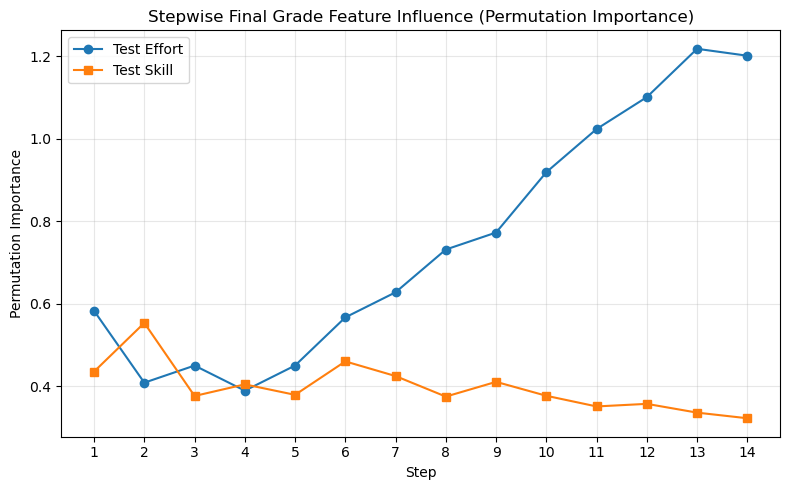

In [13]:
##########################################
##########################################
#
#       GLOBAL RIDGE REGRESSION
#      STEPWISE MODEL PERFORMANCE 
#       (PERMUTATION IMPORTANCE)
#
#        POLYNOMIAL DEGREE = 2
#           ALPHA = 0.1
#
#            CALCULATION
#
##########################################
##########################################







##########################################
# Parameters
##########################################



degree = 2

alpha = 0.1



##########################################
# Initialize
##########################################

df, max_step = initialize("student_totals_event_features_MERGED.csv")


##########################################
# Target
##########################################

y = build_target_continuous(df, max_step)



##########################################
# Split
##########################################

df_train, df_test, y_train, y_test = build_split_continuous(df, y)







##########################################
# Storage
##########################################

lin_reg_step_pi_results_list = []





##########################################
# Step Loop
##########################################

for step in range(1, max_step + 1):


    ##########################################
    # Features
    ##########################################

    
    X_train = build_features(df_train, step)

    X_test = build_features(df_test, step)


    ##########################################
    # Model
    ##########################################


    lin_reg_step_pi_model = Pipeline([
        ("polynomial_features", PolynomialFeatures(
            degree = degree,
            include_bias = False
        )),
        ("standard_scaler", StandardScaler()),
        ("ridge", Ridge(
            alpha = alpha
        ))
    ])


    lin_reg_step_pi_model.fit(X_train, y_train)


    ##########################################
    # Calculate Permutation Importance
    ##########################################


    perm_train = permutation_importance(
        lin_reg_step_pi_model,
        X_train,
        y_train,
        n_repeats = 10,
        random_state = 42,
        scoring = "r2"
    )

    

    perm_test = permutation_importance(
        lin_reg_step_pi_model,
        X_test,
        y_test,
        n_repeats = 10,
        random_state = 42,
        scoring = "r2"
    )
    

    ##########################################
    # Store Results
    ##########################################
    


    lin_reg_step_pi_results_list.append({
        "Step" : step,
        "Train Effort PI" : perm_train.importances_mean[0],
        "Train Skill PI" : perm_train.importances_mean[1],
        "Test Effort PI" : perm_test.importances_mean[0],
        "Test Skill PI" : perm_test.importances_mean[1]
    })



##########################################
# Save Results
##########################################

lin_reg_step_pi_df = pd.DataFrame(lin_reg_step_pi_results_list)








##########################################
##########################################
#
#       GLOBAL RIDGE REGRESSION
#      STEPWISE MODEL PERFORMANCE 
#       (PERMUTATION IMPORTANCE)
#
#        POLYNOMIAL DEGREE = 2
#           ALPHA = 0.1
#
#               PLOT
#
##########################################
##########################################








plt.figure(figsize = (8, 5))



##########################################
# Plot Stepwise PI
##########################################




#plt.plot(
#    lin_reg_step_pi_df["Step"],
#    lin_reg_step_pi_df["Train Effort PI"],
#    linestyle = "--",
#    marker = "o",
#    label = "Train Effort"
#)



plt.plot(
    lin_reg_step_pi_df["Step"],
    lin_reg_step_pi_df["Test Effort PI"],
    linestyle = "-",
    marker = "o",
    label = "Test Effort"
)




#plt.plot(
#    lin_reg_step_pi_df["Step"],
#    lin_reg_step_pi_df["Train Skill PI"],
#    linestyle = "--",
#    marker = "s",
#    label = "Train Skill"
#)



plt.plot(
    lin_reg_step_pi_df["Step"],
    lin_reg_step_pi_df["Test Skill PI"],
    linestyle = "-",
    marker = "s",
    label = "Test Skill"
)






##########################################
# Labels
##########################################


plt.xlabel("Step")

plt.ylabel("Permutation Importance")

plt.title(
    "Stepwise Final Grade Feature Influence (Permutation Importance)"
)



    
plt.xticks(range(1, max_step + 1))

##########################################
# Final Plot Formatting
##########################################


plt.legend(loc = "upper left")




plt.grid(alpha = 0.3)

plt.tight_layout()


plt.savefig(
    "images/15_prediction_stepwise_pi.png",
    dpi = 300,
    bbox_inches = "tight"
)


plt.show()



##########################################
# Audit
##########################################

#display(
#    lin_reg_step_pi_df
#    .set_index("Step")
#    [
#        [
#            "Train Effort PI",
#            "Train Skill PI",
#            "Test Effort PI",
#            "Test Skill PI"
#        ]
#    ]
#)






## Stepwise Feature Influence Insights

Effort and skill begin with comparable influence.

Around Step 7, effort begins to separate more clearly from skill, and that separation widens over later steps.

This suggests pacing-related behavior may become increasingly predictive as instruction progresses.

## Tiered Prediction Performance (MSE)

This analysis examines whether prediction error evolves differently across performance tiers. 

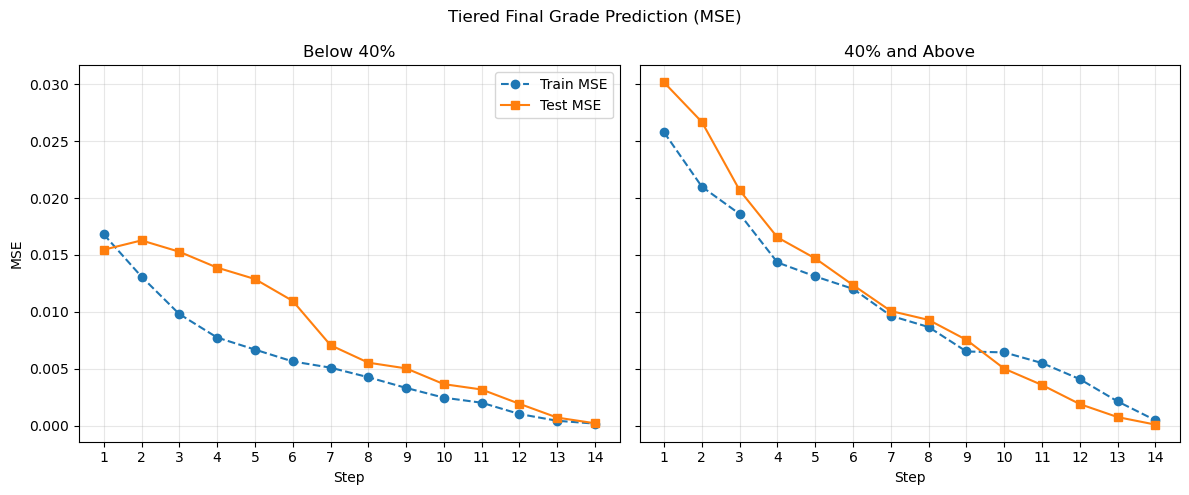

In [14]:
##########################################
##########################################
#
#       GLOBAL RIDGE REGRESSION
#       TIERED STEPWISE PERFORMANCE 
#                (MSE)
#
#        POLYNOMIAL DEGREE = 2
#           ALPHA = 0.1
#
#            CALCULATION
#
##########################################
##########################################






##########################################
# Parameters
##########################################



degree = 2

alpha = 0.1


##########################################
# Initialize
##########################################

df, max_step = initialize("student_totals_event_features_MERGED.csv")


##########################################
# Target
##########################################

y = build_target_continuous(df, max_step)



##########################################
# Create Tiers
##########################################

df["tier"] = np.where(
    y < 0.4,
    "Below 40%",
    "40% and Above"
)




##########################################
# Split
##########################################

df_train, df_test, y_train, y_test = build_split_continuous(df, y)



##########################################
# Storage
##########################################


lin_reg_tier_mse_results_list = []




##########################################
# Step Loop
##########################################

for step in range(1, max_step + 1):


    ##########################################
    # Features
    ##########################################

    
    
    X_train = build_features(df_train, step)

    X_test = build_features(df_test, step)





    ##########################################
    # Model
    ##########################################


    lin_reg_tier_mse_model = Pipeline([
        ("polynomial_features", PolynomialFeatures(
            degree = degree,
            include_bias = False
        )),
        ("standard_scaler", StandardScaler()),
        ("ridge", Ridge(
            alpha = alpha
        ))
    ])


    lin_reg_tier_mse_model.fit(X_train, y_train)


    train_preds = lin_reg_tier_mse_model.predict(X_train)
    
    test_preds = lin_reg_tier_mse_model.predict(X_test)



    ##########################################
    # Calculate Tier MSE
    ##########################################

    tier_train = df_train["tier"]
    
    tier_test = df_test["tier"]


    for tier_label in [
        "Below 40%",
        "40% and Above"
    ]:

        mask_train = (
            tier_train == tier_label
        )

        
        mask_test = (
            tier_test == tier_label
        )


        
        train_mse = mean_squared_error(
            y_train[mask_train], 
            train_preds[mask_train]
        )

        
        test_mse = mean_squared_error(
            y_test[mask_test], 
            test_preds[mask_test]
        )

        ##########################################
        # Store Results
        ##########################################


        
        lin_reg_tier_mse_results_list.append({
            "Step" : step, 
            "Tier" : tier_label,
            "Train MSE" : train_mse,
            "Test MSE" : test_mse
        })


##########################################
# Save Results
##########################################

lin_reg_tier_mse_df = pd.DataFrame(lin_reg_tier_mse_results_list)







##########################################
##########################################
#
#       GLOBAL RIDGE REGRESSION
#       TIERED STEPWISE PERFORMANCE 
#                (MSE)
#
#        POLYNOMIAL DEGREE = 2
#           ALPHA = 0.1
#
#               PLOT
#
##########################################
##########################################





##########################################
# Plot Tier MSE
##########################################

fig, axes = plt.subplots(
    1, 2, 
    figsize = (12, 5), 
    sharey = True
)


tiers = [
    "Below 40%",
    "40% and Above"
]





for ax, tier in zip(axes, tiers):

    temp = (
        lin_reg_tier_mse_df[
           lin_reg_tier_mse_df["Tier"] == tier
        ]
    )


    ax.plot(
        temp["Step"],
        temp["Train MSE"], 
        linestyle = "--",
        marker = "o",
        label = "Train MSE"
    )

    
    ax.plot(
        temp["Step"],
        temp["Test MSE"], 
        linestyle = "-",
        marker = "s",
        label = "Test MSE"
    )



    ax.set_title(tier)

    ax.set_xlabel("Step")

    ax.grid(alpha = 0.3)


        
    ax.set_xticks(range(1, max_step + 1))
    

    



axes[0].set_ylabel("MSE")

plt.suptitle(
    "Tiered Final Grade Prediction (MSE)"
)

axes[0].legend(loc = "upper right")

plt.tight_layout()


plt.savefig(
    "images/16_prediction_tiered_mse.png",
    dpi = 300,
    bbox_inches = "tight"
)



plt.show()



##########################################
# Audit Tier MSE
##########################################

#display(
#    lin_reg_tier_mse_df
#    .pivot(
#        index = "Step",
#        columns = "Tier",
#        values = ["Train MSE", "Test MSE"]
#    )
#)






## Tiered Prediction Performance Insights (MSE)

Prediction error decreases across both tiers as additional instructional information accumulates.

Students at or above 40% begin with greater initial prediction error (test MSE = 0.030 at Step 1, corresponding to approximately 17% average prediction error), while students below 40% begin with lower initial prediction error (test MSE = 0.015 at Step 1, corresponding to approximately 12% average prediction error).

The two groups become increasingly similar over time.

By Step 7, prediction error decreases to approximately 10.0% for students at or above 40% and approximately 8.4% for students below 40%.

By Steps 12-14, both tiers converge toward near-zero prediction error.

These results suggest that prediction reliability improves throughout instruction and eventually reaches comparable levels across performance groups.

## Tiered Prediction Performance (R$^2$)

This analysis examines whether predictive signal emerges differently across performance tiers.

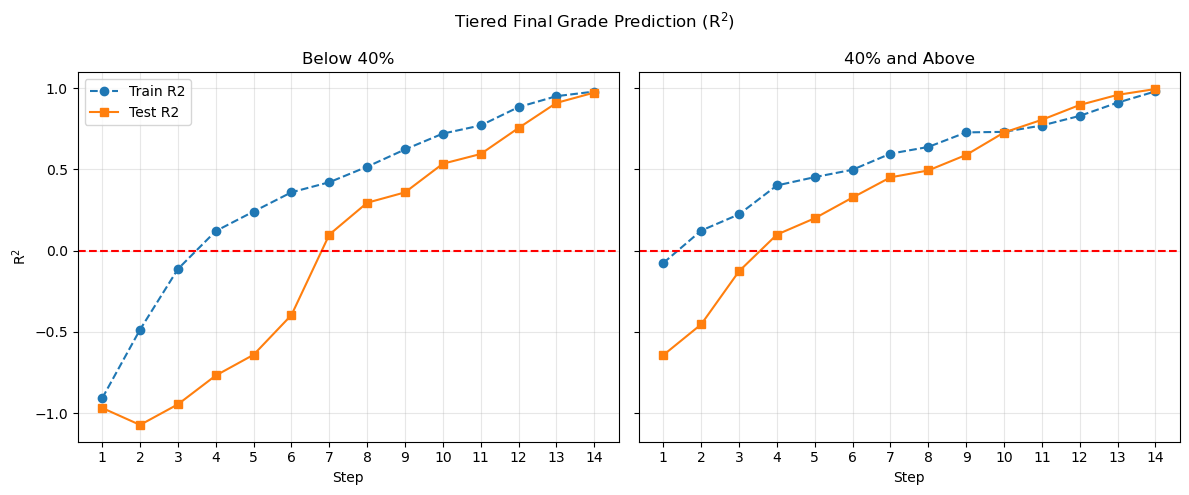

In [15]:
##########################################
##########################################
#
#       GLOBAL RIDGE REGRESSION
#       TIERED STEPWISE PERFORMANCE 
#                (R2)
#
#        POLYNOMIAL DEGREE = 2
#           ALPHA = 0.1
#
#            CALCULATION
#
##########################################
##########################################






##########################################
# Parameters
##########################################



degree = 2

alpha = 0.1


##########################################
# Initialize
##########################################

df, max_step = initialize("student_totals_event_features_MERGED.csv")


##########################################
# Target
##########################################

y = build_target_continuous(df, max_step)



##########################################
# Create Tiers
##########################################

df["tier"] = np.where(
    y < 0.4,
    "Below 40%",
    "40% and Above"
)




##########################################
# Split
##########################################

df_train, df_test, y_train, y_test = build_split_continuous(df, y)



##########################################
# Storage
##########################################


lin_reg_tier_r2_results_list = []




##########################################
# Step Loop
##########################################

for step in range(1, max_step + 1):


    ##########################################
    # Features
    ##########################################

    
    
    X_train = build_features(df_train, step)

    X_test = build_features(df_test, step)





    ##########################################
    # Model
    ##########################################


    lin_reg_tier_r2_model = Pipeline([
        ("polynomial_features", PolynomialFeatures(
            degree = degree,
            include_bias = False
        )),
        ("standard_scaler", StandardScaler()),
        ("ridge", Ridge(
            alpha = alpha
        ))
    ])


    lin_reg_tier_r2_model.fit(X_train, y_train)


    train_preds = lin_reg_tier_r2_model.predict(X_train)    
    
    test_preds = lin_reg_tier_r2_model.predict(X_test)



    ##########################################
    # Calculate Tier R2
    ##########################################

    tier_train = df_train["tier"]    
    
    tier_test = df_test["tier"]


    for tier_label in [
        "Below 40%",
        "40% and Above"
    ]:

        mask_train = (
            tier_train == tier_label
        )

        
        mask_test = (
            tier_test == tier_label
        )


        train_r2 = r2_score(
            y_train[mask_train], 
            train_preds[mask_train]
        )    

        
        test_r2 = r2_score(
            y_test[mask_test], 
            test_preds[mask_test]
        )

        ##########################################
        # Store Results
        ##########################################


        
        lin_reg_tier_r2_results_list.append({
            "Step" : step, 
            "Tier" : tier_label,
            "Train R2" : train_r2,
            "Test R2" : test_r2
        })


##########################################
# Save Results
##########################################

lin_reg_tier_r2_df = pd.DataFrame(lin_reg_tier_r2_results_list)







##########################################
##########################################
#
#       GLOBAL RIDGE REGRESSION
#       TIERED STEPWISE PERFORMANCE 
#                (R2)
#
#        POLYNOMIAL DEGREE = 2
#           ALPHA = 0.1
#
#               PLOT
#
##########################################
##########################################





##########################################
# Plot Tier R2
##########################################

fig, axes = plt.subplots(
    1, 2, 
    figsize = (12, 5), 
    sharey = True
)


tiers = [
    "Below 40%",
    "40% and Above"
]





for ax, tier in zip(axes, tiers):

    temp = (
        lin_reg_tier_r2_df[
           lin_reg_tier_r2_df["Tier"] == tier
        ]
    )

    
    ax.plot(
        temp["Step"],
        temp["Train R2"], 
        linestyle = "--",
        marker = "o",
        label = "Train R2"
    )



    
    ax.plot(
        temp["Step"],
        temp["Test R2"], 
        linestyle = "-",
        marker = "s",
        label = "Test R2"
    )

    ax.axhline(
        0,
        color = "red",
        linestyle = "--"
    )

    ax.set_title(tier)

    ax.set_xlabel("Step")

    ax.grid(alpha = 0.3)


        
    ax.set_xticks(range(1, max_step + 1))
    

    



axes[0].set_ylabel("R$^2$")

plt.suptitle(
    "Tiered Final Grade Prediction (R$^2$)"
)


axes[0].legend(loc = "upper left")

plt.tight_layout()


plt.savefig(
    "images/17_prediction_tiered_r2.png",
    dpi = 300,
    bbox_inches = "tight"
)




plt.show()



##########################################
# Audit Tier R2
##########################################

#display(
#    lin_reg_tier_r2_df
#    .pivot(
#        index = "Step",
#        columns = "Tier",
#        values = ["Train R2", "Test R2"]
#    )
#)






## Tiered Prediction Performance Insights (R$^2$)

Signal appears to emerge earlier for students at or above 40% than for students below 40%.

For the 40%-and-above tier, positive predictive signal appears around Step 4 (roughly quarter-course).

For the below-40% tier, comparable signal does not emerge until approximately Step 7 (half-course).

The asymmetry has possible implications for intervention timing. 

## Tiered Feature Influence (Permutation Importance)

This analysis examines whether effort and skill influence differ structurally across tiers. 

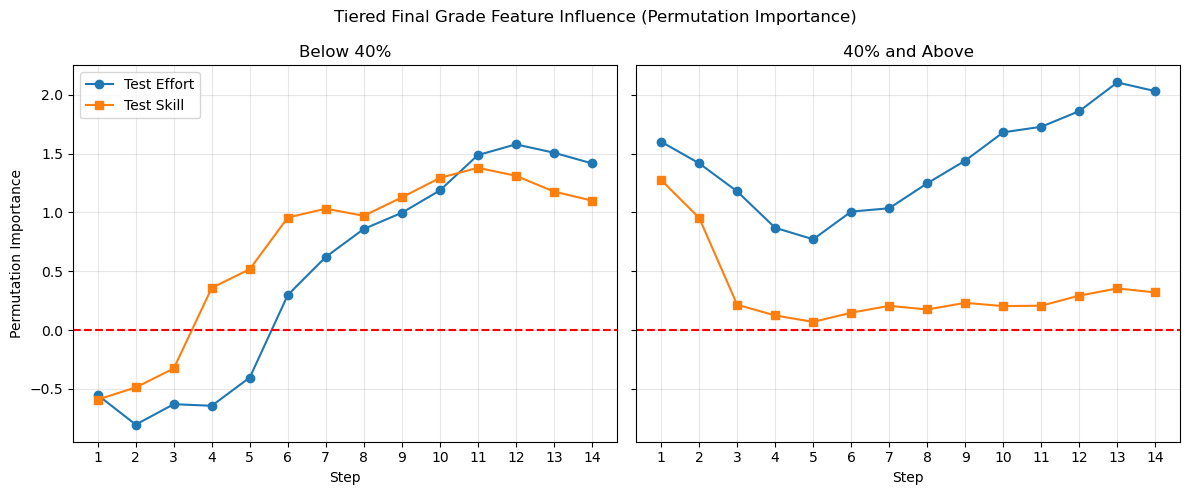

In [16]:
##########################################
##########################################
#
#       GLOBAL RIDGE REGRESSION
#     TIERED STEPWISE FEATURE INFLUENCE 
#        (PERMUTATION IMPORTANCE)
#
#        POLYNOMIAL DEGREE = 2
#           ALPHA = 0.1
#
#            CALCULATION
#
##########################################
##########################################






##########################################
# Parameters
##########################################



degree = 2

alpha = 0.1


##########################################
# Initialize
##########################################

df, max_step = initialize("student_totals_event_features_MERGED.csv")


##########################################
# Target
##########################################

y = build_target_continuous(df, max_step)




##########################################
# Create Tiers
##########################################

df["tier"] = np.where(
    y < 0.4,
    "Below 40%",
    "40% and Above"
)




##########################################
# Split
##########################################

df_train, df_test, y_train, y_test = build_split_continuous(df, y)



##########################################
# Storage
##########################################


lin_reg_tier_pi_results_list = []




##########################################
# Step Loop
##########################################

for step in range(1, max_step + 1):


    ##########################################
    # Features
    ##########################################

    
    
    X_train = build_features(df_train, step)

    X_test = build_features(df_test, step)





    ##########################################
    # Model
    ##########################################


    lin_reg_tier_pi_model = Pipeline([
        ("polynomial_features", PolynomialFeatures(
            degree = degree,
            include_bias = False
        )),
        ("standard_scaler", StandardScaler()),
        ("ridge", Ridge(
            alpha = alpha
        ))
    ])


    lin_reg_tier_pi_model.fit(X_train, y_train)




    ##########################################
    # Calculate Tier PI
    ##########################################

    tier_train = df_train["tier"]
    
    tier_test = df_test["tier"]


    for tier_label in [
        "Below 40%",
        "40% and Above"
    ]:

    
        mask_train = (
            tier_train == tier_label
        )
        
        mask_test = (
            tier_test == tier_label
        )
    
        ##########################################
        # Tier Subset
        ##########################################


        X_train_tier = X_train[mask_train]

        y_train_tier = y_train[mask_train]
        
        

        X_test_tier = X_test[mask_test]

        y_test_tier = y_test[mask_test]


        perm_train = permutation_importance(
            lin_reg_tier_pi_model,
            X_train_tier,
            y_train_tier,
            n_repeats = 10,
            random_state = 42,
            scoring = "r2"
        )


        
        perm_test = permutation_importance(
            lin_reg_tier_pi_model,
            X_test_tier,
            y_test_tier,
            n_repeats = 10,
            random_state = 42,
            scoring = "r2"
        )


        


        ##########################################
        # Store Results
        ##########################################


        
        lin_reg_tier_pi_results_list.append({
            "Step" : step, 
            "Tier" : tier_label,
            "Train Effort PI" : perm_train.importances_mean[0],
            "Train Skill PI" : perm_train.importances_mean[1],
            "Test Effort PI" : perm_test.importances_mean[0],
            "Test Skill PI" : perm_test.importances_mean[1]
        })


##########################################
# Save Results
##########################################

lin_reg_tier_pi_df = pd.DataFrame(lin_reg_tier_pi_results_list)







##########################################
##########################################
#
#       GLOBAL RIDGE REGRESSION
#     TIERED STEPWISE FEATURE INFLUENCE 
#       (PERMUTATION IMPORTANCE)
#
#        POLYNOMIAL DEGREE = 2
#           ALPHA = 0.1
#
#               PLOT
#
##########################################
##########################################





##########################################
# Plot Tier PI
##########################################

fig, axes = plt.subplots(
    1, 2, 
    figsize = (12, 5), 
    sharey = True
)


tiers = [
    "Below 40%",
    "40% and Above"
]





for ax, tier in zip(axes, tiers):

    temp = (
        lin_reg_tier_pi_df[
           lin_reg_tier_pi_df["Tier"] == tier
        ]
    )

#    ax.plot(
#        temp["Step"],
#        temp["Train Effort PI"], 
#        linestyle = "--",
#        marker = "o",
#        label = "Train Effort"
#    )
    

    
    ax.plot(
        temp["Step"],
        temp["Test Effort PI"], 
        linestyle = "-",
        marker = "o",
        label = "Test Effort"
    )


#    ax.plot(
#        temp["Step"],
#        temp["Train Skill PI"], 
#        linestyle = "--",
#        marker = "s",
#        label = "Train Skill"
#    )



    ax.plot(
        temp["Step"],
        temp["Test Skill PI"], 
        linestyle = "-",
        marker = "s",
        label = "Test Skill"
    )
    
    ax.axhline(
        0,
        color = "red",
        linestyle = "--"
    )

    ax.set_title(tier)

    ax.set_xlabel("Step")

    ax.grid(alpha = 0.3)


    
    ax.set_xticks(range(1, max_step + 1))




axes[0].set_ylabel("Permutation Importance")

plt.suptitle(
    "Tiered Final Grade Feature Influence (Permutation Importance)"
)

axes[0].legend(loc = "upper left")

plt.tight_layout()


plt.savefig(
    "images/18_prediction_tiered_pi.png",
    dpi = 300,
    bbox_inches = "tight"
)




plt.show()



##########################################
# Audit Effort PI
##########################################

#display(
#    lin_reg_tier_pi_df
#    .pivot(
#        index = "Step",
#        columns = "Tier",
#        values = ["Train Effort PI", "Test Effort PI"]
#    )
#)


##########################################
# Audit Skill PI
##########################################

#display(
#    lin_reg_tier_pi_df
#    .pivot(
#        index = "Step",
#        columns = "Tier",
#        values = ["Train Skill PI", "Test Skill PI"]
#    )
#)



## Tiered Feature Influence Insights

For students at or above 40%, effort exhibits consistently greater influence than skill.

For students below 40%, effort and skill remain much closer in magnitude, with less pronounced separation.

This suggests potentially different structural dynamics may characterize successful versus struggling trajectories. 

## Prediction Modeling Summary

Across the modeling analyses, four patterns emerge:

- Prediction error decreases steadily over instructional time.

- Predictive signal strengthens surprisingly early, with meaningful grade estimation emerging by approximately Step 7.

- Effort and skill exhibit comparable influence early but separate over time.

- Signal emergence and prediction accuracy evolve differently across performance tiers before converging later in instruction.

Together, these results motivate downstream classification modeling as a natural next step.

## Classification Modeling

This section extends the earlier regression analyses into classification modeling.

Logistic regression is used to study risk classification, intervention-oriented prediction, and how classification reliability evolves over instructional time.

In [17]:
##########################################
##########################################
#
#    CLASSIFICATION HELPER FUNCTIONS
#
##########################################
##########################################




def build_target_classification(df, max_step, threshold = 0.40):

    ##########################################
    # Calculate Final Mastery
    ##########################################
    

    final_mastery = (

        0.25 * df["final_quarter"] +
        0.50 * df["final_half"] +
        1.00 * df["final_full"]
    )


    ##########################################
    # Calculate Final Expectation
    ##########################################    

    final_expectation = (
        max_step * QUESTIONS_PER_STEP
    )



    ##########################################
    # Calculate Final Grade
    ##########################################   


    final_grade = (
        final_mastery / final_expectation
    )


    final_grade = (
        final_grade
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    

    ##########################################
    # Build Classification Target
    ##########################################   


    y = (
        final_grade < threshold
    ).astype(int)

    return y

    



    




def build_split_classification(df, y):


    ##########################################
    # Train-Test Split
    ##########################################   
    
    df_train, df_test, y_train, y_test = train_test_split(

        df, 
        y, 
        test_size = 0.2,
        random_state = 42,
        stratify = y
    )

    return df_train, df_test, y_train, y_test




## Logistic Model Selection

This analysis uses cross-validated logistic regression with polynomial features to study classification performance across model complexity and regularization settings. 

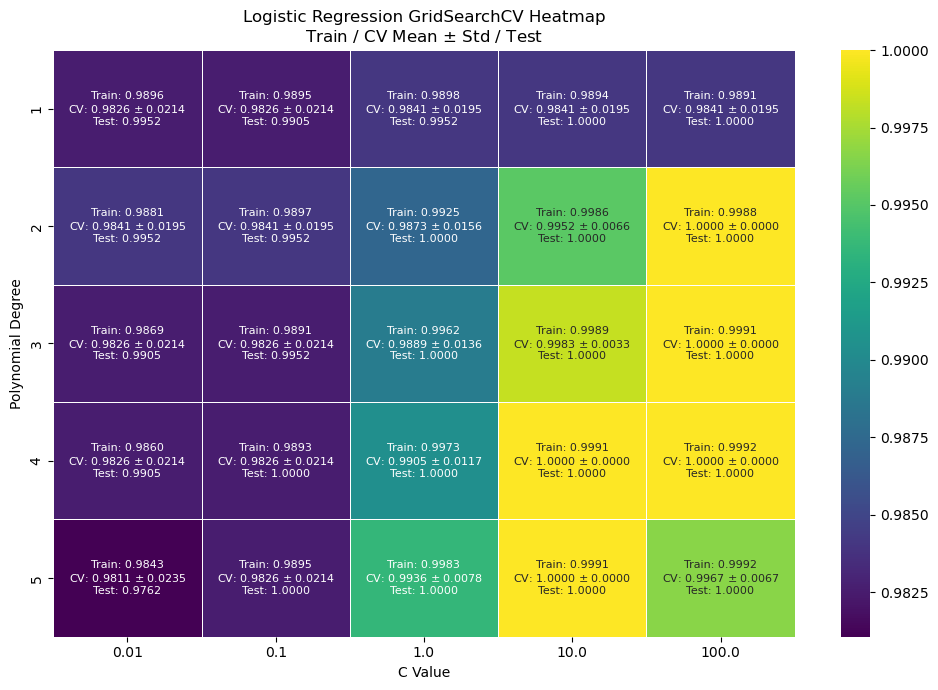


Best Parameters
{'logistic_regression__C': 10, 'polynomial_features__degree': 4}


In [18]:
##########################################
##########################################
#
#          LOGISTIC REGRESSION
#
#        GRIDSEARCHCV HEATMAP
#
#            CALCULATION
#
##########################################
##########################################





##########################################
# Parameters
##########################################


degrees = [1, 2, 3, 4, 5]

C_values = [0.01, 0.1, 1, 10, 100]


##########################################
# Initialize
##########################################

df, max_step = initialize("student_totals_event_features_MERGED.csv")


##########################################
# Target
##########################################

y = build_target_classification(df, max_step)



##########################################
# Split
##########################################

df_train, df_test, y_train, y_test = build_split_classification(df, y)



##########################################
# Features
##########################################

X_train = build_features(df_train, max_step)


X_test = build_features(df_test, max_step)




##########################################
# Pipeline
##########################################


log_reg_grid_pipeline = Pipeline([
    ("polynomial_features", PolynomialFeatures(
        include_bias = False
    )),
    ("standard_scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        max_iter = 10000
    ))
])




##########################################
# Parameter Grid
##########################################

param_grid = {
    "polynomial_features__degree" : degrees,
    "logistic_regression__C" : C_values
}


##########################################
# Grid Search
##########################################


log_reg_grid_search = GridSearchCV(
    estimator = log_reg_grid_pipeline,
    param_grid = param_grid,
    scoring = "roc_auc",
    cv = 5,
    return_train_score = True
)



log_reg_grid_search.fit(X_train, y_train)



##########################################
# Save Results
##########################################

logistic_heat_df = pd.DataFrame(
    log_reg_grid_search.cv_results_
)



logistic_heat_df["Train ROC-AUC"] = logistic_heat_df["mean_train_score"]


logistic_heat_df["CV ROC-AUC"] = logistic_heat_df["mean_test_score"]


logistic_heat_df["CV Std"] = logistic_heat_df["std_test_score"]





##########################################
# Calculate Grid Test ROC-AUC
##########################################


logistic_test_auc_list = []


for _, row in logistic_heat_df.iterrows():

    degree = row["param_polynomial_features__degree"]

    C_value = row["param_logistic_regression__C"]


    log_reg_grid_model = Pipeline([
        ("polynomial_features", PolynomialFeatures(
            degree = degree,
            include_bias = False
        )),
        ("standard_scaler", StandardScaler()),
        ("logistic_regression", LogisticRegression(
            C = C_value,
            max_iter = 10000
        ))
    ])

    log_reg_grid_model.fit(X_train, y_train)

    grid_test_probs = log_reg_grid_model.predict_proba(X_test)[:, 1]

    test_auc = roc_auc_score(
        y_test,
        grid_test_probs
    )

    logistic_test_auc_list.append(
        test_auc
    )






logistic_heat_df["Test ROC-AUC"] = logistic_test_auc_list






##########################################
##########################################
#
#          LOGISTIC REGRESSION
#
#        GRIDSEARCHCV HEATMAP
#
#               PLOT
#
##########################################
##########################################


##########################################
# Create Heatmap Labels
##########################################


logistic_heat_df["label"] = logistic_heat_df.apply(
    lambda row: (
        f"Train: {row['Train ROC-AUC']:.4f}\n"
        f"CV: {row['CV ROC-AUC']:.4f} $\pm$ {row['CV Std']:.4f}\n"
        f"Test: {row['Test ROC-AUC']:.4f}"
    ),
    axis = 1
)




##########################################
# Pivot Tables
##########################################


logistic_mean_table = logistic_heat_df.pivot(
    index = "param_polynomial_features__degree",
    columns = "param_logistic_regression__C",
    values = "CV ROC-AUC"
)


logistic_label_table = logistic_heat_df.pivot(
    index = "param_polynomial_features__degree",
    columns = "param_logistic_regression__C",
    values = "label"
)



##########################################
# Heatmap
##########################################



plt.figure(figsize = (10, 7))


sns.heatmap(
    logistic_mean_table,
    annot = logistic_label_table,
    fmt = "",
    cmap = "viridis",
    linewidths = 0.5,
    linecolor = "white",
    annot_kws = {"fontsize" : 8}
)



plt.title(
    "Logistic Regression GridSearchCV Heatmap\n"
    "Train / CV Mean $\pm$ Std / Test"
)


plt.xlabel("C Value")
plt.ylabel("Polynomial Degree")



plt.tight_layout()



plt.savefig(
    "images/21_classification_logistic_gridsearchcv_heatmap.png",
    dpi = 300,
    bbox_inches = "tight"
)


plt.show()







##########################################
# Audit 
##########################################


#display(
#    logistic_heat_df
#    .set_index(
#        [
#            "param_polynomial_features__degree",
#            "param_logistic_regression__C"
#        ]
#    )
#    [
#        [
#            "Train ROC-AUC", 
#            "CV ROC-AUC",
#            "CV Std",
#            "Test ROC-AUC"
#        ]
#    ]
#    .sort_values(
#        by = "CV ROC-AUC",
#        ascending = False
#    )
#)


print("\nBest Parameters")
print(log_reg_grid_search.best_params_)








## Logistic Model Selection Insights

The GridSearchCV heatmap suggests that low-degree polynomial models provide strong predictive performance with limited evidence of instability.

Although higher-degree models achieved near-perfect ROC-AUC values, degree = 2 provided comparable performance while maintaining a simpler and more interpretable decision surface.

Across many parameter combinations, both cross-validation and test ROC-AUC values remained extremely high, suggesting strong separability within the engineered feature space.

Because degree = 2 and C = 1 produced strong and stable performance while limiting unnecessary complexity, that configuration was selected for downstream analyses.

## Stepwise Classification Performance (ROC-AUC)

This analysis examines how classification performance evolves over instructional time.

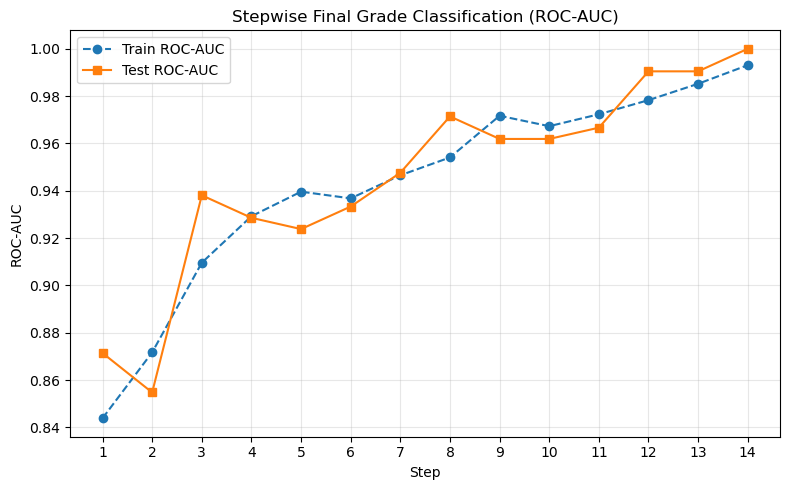

In [19]:
##########################################
##########################################
#
#      GLOBAL LOGISTIC REGRESSION
#      STEPWISE MODEL PERFORMANCE 
#             (ROC-AUC)
#
#        POLYNOMIAL DEGREE = 2
#              C = 1
#
#            CALCULATION
#
##########################################
##########################################







##########################################
# Parameters
##########################################



degree = 2

C_value = 1



##########################################
# Initialize
##########################################

df, max_step = initialize("student_totals_event_features_MERGED.csv")


##########################################
# Target
##########################################

y = build_target_classification(df, max_step)



##########################################
# Split
##########################################

df_train, df_test, y_train, y_test = build_split_classification(df, y)







##########################################
# Storage
##########################################

log_reg_step_auc_results_list = []





##########################################
# Step Loop
##########################################

for step in range(1, max_step + 1):


    ##########################################
    # Features
    ##########################################

    
    X_train = build_features(df_train, step)

    X_test = build_features(df_test, step)


    ##########################################
    # Model
    ##########################################


    log_reg_step_auc_model = Pipeline([
        ("polynomial_features", PolynomialFeatures(
            degree = degree,
            include_bias = False
        )),
        ("standard_scaler", StandardScaler()),
        ("logistic_regression", LogisticRegression(
            C = C_value,
            max_iter = 10000
        ))
    ])


    log_reg_step_auc_model.fit(X_train, y_train)





    
    ##########################################
    # Calculate ROC-AUC
    ##########################################


    train_probs = log_reg_step_auc_model.predict_proba(X_train)[:, 1]

    test_probs = log_reg_step_auc_model.predict_proba(X_test)[:, 1]


    train_auc = roc_auc_score(y_train, train_probs)

    test_auc = roc_auc_score(y_test, test_probs)


    ##########################################
    # Store Results
    ##########################################
    


    log_reg_step_auc_results_list.append({
        "Step" : step,
        "Train ROC-AUC" : train_auc,
        "Test ROC-AUC" : test_auc
    })




##########################################
# Save Results
##########################################

log_reg_step_auc_df = pd.DataFrame(log_reg_step_auc_results_list)




##########################################
##########################################
#
#      GLOBAL LOGISTIC REGRESSION
#      STEPWISE MODEL PERFORMANCE 
#             (ROC-AUC)
#
#        POLYNOMIAL DEGREE = 2
#               C = 1
#
#               PLOT
#
##########################################
##########################################





plt.figure(figsize = (8, 5))


##########################################
# Plot Stepwise ROC-AUC
##########################################


plt.plot(
    log_reg_step_auc_df["Step"],
    log_reg_step_auc_df["Train ROC-AUC"],
    linestyle = "--",
    marker = "o",
    label = "Train ROC-AUC"
)




plt.plot(
    log_reg_step_auc_df["Step"],
    log_reg_step_auc_df["Test ROC-AUC"],
    linestyle = "-",
    marker = "s",
    label = "Test ROC-AUC"
)



##########################################
# Labels
##########################################

plt.xlabel("Step")

plt.ylabel("ROC-AUC")

plt.title(
    "Stepwise Final Grade Classification (ROC-AUC)"
)

    
plt.xticks(range(1, max_step + 1))






##########################################
# Final Plot Formatting
##########################################


plt.legend(loc = "upper left")

plt.grid(alpha = 0.3)




plt.tight_layout()


plt.savefig(
    "images/22_classification_stepwise_roc_auc.png",
    dpi = 300,
    bbox_inches = "tight"
)



plt.show()



##########################################
# Audit
##########################################

#display(
#    log_reg_step_auc_df
#    .set_index("Step")
#    [
#        [
#            "Train ROC-AUC",
#            "Test ROC-AUC"
#        ]
#    ]
#)






## Stepwise Classification Performance Insights (ROC-AUC)

Classification performance strengthens steadily across steps.

Even during early instructional steps, ROC-AUC values exceed 0.85, suggesting meaningful predictive structure emerges surprisingly early.

Performance continues improving over time, with near-perfect classification performance emerging during later steps.

The progression suggests intervention-oriented signal accumulates gradually as additional behavioral and performance information becomes available.

## Stepwise Confusion Counts

This analysis examines how true positives, false positives, true negatives, and false negatives evolve across instructional time. 

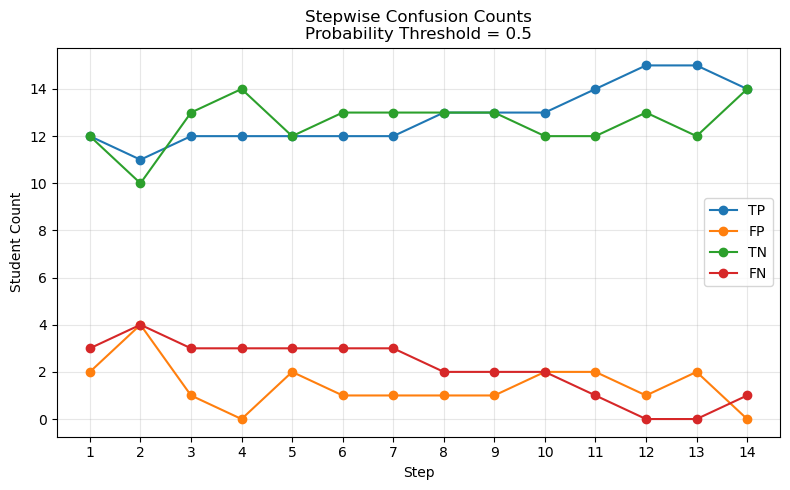

In [20]:
##########################################
##########################################
#
#      GLOBAL LOGISTIC REGRESSION
#       STEPWISE CONFUSION COUNTS
#
#        POLYNOMIAL DEGREE = 2
#              C = 1
#
#             CALCULATION
#
##########################################
##########################################







##########################################
# Parameters
##########################################



degree = 2

C_value = 1

probability_threshold = 0.50



##########################################
# Initialize
##########################################

df, max_step = initialize("student_totals_event_features_MERGED.csv")


##########################################
# Target
##########################################

y = build_target_classification(df, max_step)



##########################################
# Split
##########################################

df_train, df_test, y_train, y_test = build_split_classification(df, y)




##########################################
# Storage
##########################################


log_reg_step_confusion_results_list = []


##########################################
# Step Loop
##########################################

for step in range(1, max_step + 1):



    ##########################################
    # Features
    ##########################################
    
    X_train = build_features(
        df_train,
        step
    )
    
    
    X_test = build_features(
        df_test,
        step
    )
    
    
    
    
    ##########################################
    # Model
    ##########################################
    
    log_reg_step_confusion_model = Pipeline([
    
        ("polynomial_features", PolynomialFeatures(
            degree = degree,
            include_bias = False
        )),
    
        ("standard_scaler", StandardScaler()),
    
        ("logistic_regression", LogisticRegression(
            C = C_value,
            max_iter = 10000
        ))
    ])
    
    
    
    log_reg_step_confusion_model.fit(
        X_train,
        y_train
    )


    ##########################################
    # Probabilities
    ##########################################


    test_probs = (

        log_reg_step_confusion_model
        .predict_proba(X_test)[:, 1]
    )
    


    ##########################################
    # Threshold Predictions
    ##########################################

    y_pred = (
        test_probs >= probability_threshold
    ).astype(int)


    ##########################################
    # Confusion Matrix
    ##########################################

    tn, fp, fn, tp = (
        confusion_matrix(
            y_test,
            y_pred
        )
    .ravel()
    )

    

    ##########################################
    # Store Results
    ##########################################
    


    log_reg_step_confusion_results_list.append({
        "Step" : step,
        "TP" : tp,
        "FP" : fp,
        "TN" : tn,
        "FN" : fn 
    })




##########################################
# Save Results
##########################################

log_reg_step_confusion_df = pd.DataFrame(log_reg_step_confusion_results_list)







##########################################
##########################################
#
#      GLOBAL LOGISTIC REGRESSION
#       STEPWISE CONFUSION COUNTS
#
#        POLYNOMIAL DEGREE = 2
#              C = 1
#
#               PLOT
#
##########################################
##########################################



plt.figure(figsize = (8, 5))


plt.plot(
    log_reg_step_confusion_df["Step"],
    log_reg_step_confusion_df["TP"],
    marker = "o",
    label = "TP"
)

plt.plot(
    log_reg_step_confusion_df["Step"],
    log_reg_step_confusion_df["FP"],
    marker = "o",
    label = "FP"
)

plt.plot(
    log_reg_step_confusion_df["Step"],
    log_reg_step_confusion_df["TN"],
    marker = "o",
    label = "TN"
)

plt.plot(
    log_reg_step_confusion_df["Step"],
    log_reg_step_confusion_df["FN"],
    marker = "o",
    label = "FN"
)








##########################################
# Labels
##########################################

plt.xlabel("Step")

plt.ylabel("Student Count")

plt.title(
    "Stepwise Confusion Counts\n"
    f"Probability Threshold = {probability_threshold}"
)



plt.xticks(
    range(1, max_step + 1)
)




##########################################
# Final Plot Formatting
##########################################

plt.legend(loc = "center right")

plt.grid(alpha = 0.3)

plt.tight_layout()


plt.savefig(
    "images/23_classification_stepwise_confusion_counts.png",
    dpi = 300,
    bbox_inches = "tight"
)



plt.show()




##########################################
# Audit
##########################################

#display(
#    log_reg_step_confusion_df
#    .set_index("Step")
#    [
#        [
#            "TP",
#            "FP",
#            "TN",
#            "FN"
#        ]
#    ]
#)






## Stepwise Confusion Counts Insights

Classification behavior appears to stabilize gradually across the instructional sequence.

Earlier steps exhibit greater variability in false positives and false negatives, suggesting intervention-oriented prediction remains relatively unstable when limited information is available.

As additional instructional data accumulates, false negatives generally decrease while true positives remain consistently high during later steps.

The progression suggests intervention reliability improves over time, with later instructional stages producing increasingly stable classification behavior. 

## Final Classification Decision Boundary and Confusion Matrix

This analysis visualizes the logistic regression decision surface alongside final classification outcomes.

The decision boundary plot illustrates how effort and skill combine to separate predicted intervention outcomes, while the confusion matrix summarizes overall classification performance.

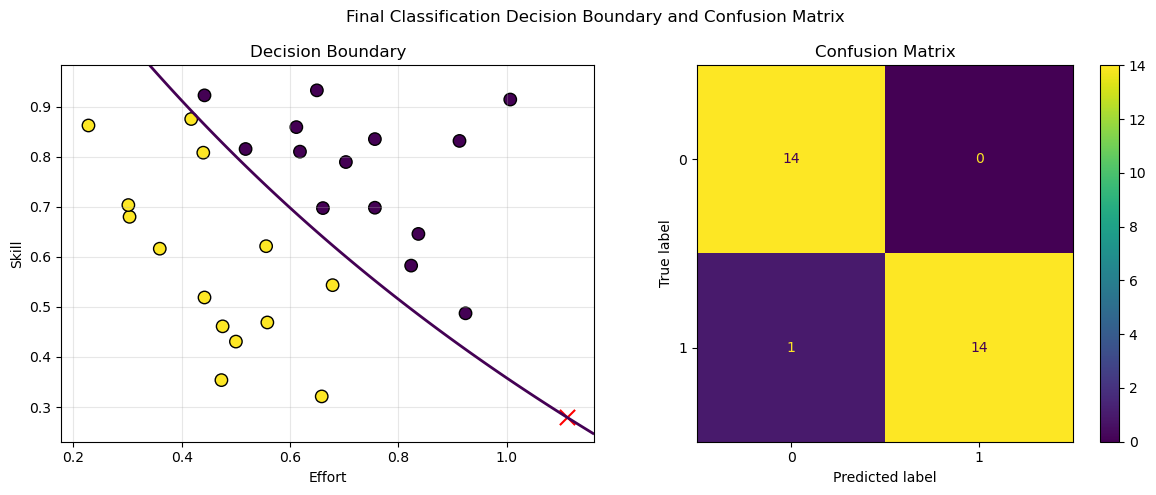

In [21]:
##########################################
##########################################
#
#      GLOBAL LOGISTIC REGRESSION
#  DECISION BOUNDARY AND CONFUSION MATRIX
#
#        POLYNOMIAL DEGREE = 2
#              C = 1
#
#            CALCULATION
#
##########################################
##########################################







##########################################
# Parameters
##########################################



degree = 2

C_value = 1



##########################################
# Initialize
##########################################

df, max_step = initialize("student_totals_event_features_MERGED.csv")


##########################################
# Target
##########################################

y = build_target_classification(df, max_step)



##########################################
# Split
##########################################

df_train, df_test, y_train, y_test = build_split_classification(df, y)





##########################################
# Features
##########################################

    
X_train = build_features(df_train, max_step)

X_test = build_features(df_test, max_step)


##########################################
# Model
##########################################


log_reg_model = Pipeline([
    ("polynomial_features", PolynomialFeatures(
        degree = degree,
        include_bias = False
    )),
    ("standard_scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        C = C_value,
        max_iter = 10000
    ))
])


log_reg_model.fit(X_train, y_train)






##########################################
# Predictions
##########################################


y_pred = log_reg_model.predict(X_test)




##########################################
# Confusion Matrix
##########################################



cm = confusion_matrix(y_test, y_pred)









##########################################
# Mesh Grid
##########################################


x_min = X_test["effort"].min() - 0.05
x_max = X_test["effort"].max() + 0.05


y_min = X_test["skill"].min() - 0.05
y_max = X_test["skill"].max() + 0.05


xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)




##########################################
# Grid Data
##########################################



grid_df = pd.DataFrame({
    "effort" : xx.ravel(),
    "skill" : yy.ravel()
})




##########################################
# Probability Surface
##########################################



Z = (

    log_reg_model
    .predict_proba(grid_df)[:, 1]
    .reshape(xx.shape)
)




##########################################
# Correct / Wrong Masks
##########################################

correct = (y_pred == y_test)

wrong = (y_pred != y_test)






##########################################
##########################################
#
#      GLOBAL LOGISTIC REGRESSION
#  DECISION BOUNDARY AND CONFUSION MATRIX
#
#
#        POLYNOMIAL DEGREE = 2
#              C = 1
#
#                PLOT
#
##########################################
##########################################





fig, axes = plt.subplots(
    1, 2, 
    figsize = (12, 5)
)









##########################################
# LEFT: Decision Boundary
##########################################


axes[0].contour(
    xx,
    yy,
    Z,
    levels = [0.5],
    linewidths = 2
)



##########################################
# LEFT: Correct Predictions
##########################################


axes[0].scatter(
    X_test["effort"][correct],
    X_test["skill"][correct],
    c = y_test[correct],
    s = 80,
    edgecolor = "black"
)




##########################################
# LEFT: Wrong Predictions
##########################################

axes[0].scatter(
    X_test["effort"][wrong],
    X_test["skill"][wrong],
    color = "red",
    marker = "x",
    s = 120
)



##########################################
# LEFT: Labels
##########################################


axes[0].set_title(
    "Decision Boundary"
)

axes[0].set_xlabel("Effort")
axes[0].set_ylabel("Skill")

axes[0].grid(alpha = 0.3)



##########################################
# RIGHT: Confusion Matrix
##########################################


ConfusionMatrixDisplay(
    cm
).plot(
    ax = axes[1]
)

##########################################
# RIGHT: Labels
##########################################


axes[1].set_title(
    "Confusion Matrix"
)



##########################################
# Layout
##########################################


plt.suptitle(
    "Final Classification Decision Boundary and Confusion Matrix"
)

plt.tight_layout()


plt.savefig(
    "images/24_classification_final_decision_boundary_confusion_matrix.png",
    dpi = 300,
    bbox_inches = "tight"
)


plt.show()






##########################################
# Audit
##########################################



#tn, fp, fn, tp = cm.ravel()

#print("Confusion Matrix Audit")
#print(f"TP: {tp}")
#print(f"FP: {fp}")
#print(f"TN: {tn}")
#print(f"FN: {fn}")








## Final Classification Decision Boundary and Confusion Matrix Insights

The selected logistic model produces strong overall classification performance, with only a small number of classification errors at the final instructional step.

Classification errors occur near the decision boundary itself, suggesting uncertainty is concentrated among borderline trajectories rather than clear cases.

One notable false negative occurred for a high-effort but low-skill student, suggesting strong effort alone may sometimes resemble successful trajectories despite continued academic risk.

Taken together, the decision boundary and confusion matrix suggest the model captures substantial structure while still preserving realistic uncertainty near difficult edge cases.

## Classification Modeling Summary

Across the classification analyses, several patterns emerge:

- Classification signal strengthens steadily over time.

- Strong intervention-oriented signal emerges well before final outcomes are observed.

- Most classification uncertainty occurs near the decision boundary itself.

- Effort and skill jointly produce interpretable intervention regions.

Together, these results suggest that event-level assessment behavior contains meaningful structure for early risk classification and intervention-oriented decision support. 

## Intervention Proof of Concept (POC)

This section explores whether prediction and classification outputs can be translated into an intervention-oriented framework.

Predicted grade, classification risk, and event-level behavioral patterns are combined to construct interpretable student profiles over instructional time.

Rather than focusing on individual observations, the goal is to evaluate whether model outputs can be summarized into meaningful intervention signals that may support earlier instructional decision making.

In [22]:
##########################################
##########################################
#
#            INTERVENTION POC
#
##########################################
##########################################



##########################################
# Parameters
##########################################

QUESTIONS_PER_STEP = 32

ridge_degree = 2

ridge_alpha = 0.1

log_degree = 2

log_C = 1

EFFORT_THRESHOLD = 0.5

SKILL_THRESHOLD = 0.5

##########################################
# Initialize
##########################################

df, max_step = initialize("student_totals_event_features_MERGED.csv")

##########################################
# Final Grade
##########################################

df["actual_grade"] = build_target_continuous(df, max_step)

##########################################
# Risk Target
##########################################

df["risk_flag"] = build_target_classification(df, max_step)

##########################################
# Stepwise Prediction
##########################################



for step in range(1, max_step + 1):

    ##########################################
    # Step Features
    ##########################################

    attempts_running = 0

    mastery_running = 0

    for i in range(1, step + 1):

        attempts_i = df[f"new_attempts_step_{i}"]

        accuracy_i = df[f"new_accuracy_step_{i}"].fillna(0)

        attempts_running += attempts_i

        mastery_running += attempts_i * accuracy_i

    
    effort_step = attempts_running / (step * QUESTIONS_PER_STEP)
    
    skill_step = (mastery_running / attempts_running.replace(0, np.nan)).fillna(0)


    X_step = pd.DataFrame({

        "effort" : effort_step,
        "skill" : skill_step
    })

    ##########################################
    # Ridge Model
    ##########################################

    pred_model = Pipeline([
        ("polynomial_features", PolynomialFeatures(
            degree = ridge_degree,
            include_bias = False
        )),
        ("standard_scaler", StandardScaler()),
        ("ridge", Ridge(
            alpha = ridge_alpha
        ))
    ])

    pred_model.fit(
        X_step,
        df["actual_grade"]
    )

    pred_grade = pred_model.predict(X_step)


    pred_col = f"pred_grade_step_{step}"

    df[pred_col] = pred_grade


    ##########################################
    # Logistic Model
    ##########################################

    risk_model = Pipeline([
        ("polynomial_features", PolynomialFeatures(
            degree = log_degree,
            include_bias = False
        )),
        ("standard_scaler", StandardScaler()),
        ("logistic_regression", LogisticRegression(
            C = log_C,
            max_iter = 10000
        ))
    ])

    risk_model.fit(
        X_step,
        df["risk_flag"]
    )

    risk_probs = risk_model.predict_proba(X_step)[:, 1]


    risk_col = f"risk_step_{step}"

    df[risk_col] = risk_probs


##########################################
# Prediction Summaries
##########################################

df["current_pred_grade"] = (
    df[f"pred_grade_step_{max_step}"]
)

df["current_risk"] = (
    df[f"risk_step_{max_step}"]
)

##########################################
# Mode Counters
##########################################

zero_counts = []

stall_counts = []

spam_counts = []

coast_counts = []

surge_counts = []

for idx in range(len(df)):

    zero = 0
    stall = 0
    spam = 0
    coast = 0
    surge = 0

    for step in range(1, max_step + 1):

        attempts = df[f"new_attempts_step_{step}"].iloc[idx]

        accuracy = df[f"new_accuracy_step_{step}"].iloc[idx]

        if pd.isna(accuracy):

            accuracy = 0

        
        effort_event = attempts / QUESTIONS_PER_STEP

        skill_event = accuracy
        

        if attempts == 0:

            zero += 1

        elif effort_event < EFFORT_THRESHOLD and skill_event < SKILL_THRESHOLD:

            stall += 1

        elif effort_event >= EFFORT_THRESHOLD and skill_event < SKILL_THRESHOLD:

            spam += 1

        elif effort_event < EFFORT_THRESHOLD and skill_event >= SKILL_THRESHOLD:

            coast += 1

        else:

            surge += 1

    zero_counts.append(zero)

    stall_counts.append(stall)

    spam_counts.append(spam)

    coast_counts.append(coast)

    surge_counts.append(surge)

##########################################
# Store Mode Counts
##########################################

df["zero_count"] = zero_counts

df["stall_count"] = stall_counts

df["spam_count"] = spam_counts

df["coast_count"] = coast_counts

df["surge_count"] = surge_counts

##########################################
# Final Intervention Table
##########################################

intervention_poc_df = (

    df[[

        "last_name",
        "first_name",
        "student_id",

        "risk_flag",
        
        "current_pred_grade",
        "current_risk",

        "zero_count",
        "stall_count",
        "spam_count",
        "coast_count",
        "surge_count"
        
    ]]
  
    .sort_values(
        by = [
            
            "current_risk",
            "current_pred_grade"
            
        ],
        ascending = [
            
            False,
            True
            
        ]
    )

)

##########################################
# Audit
##########################################

#display(intervention_poc_df)



In [23]:
##########################################
##########################################
#
#        INTERVENTION ARCHETYPES
#
##########################################
##########################################




##########################################
# Calculate
##########################################

archetype_summary_df = (

    intervention_poc_df

    .groupby(
        
        "risk_flag"
        
    )

    .agg({

        "current_pred_grade" : "mean",
        "current_risk" : "mean",
        "zero_count" : "mean",
        "stall_count" : "mean",
        "spam_count" : "mean",
        "coast_count" : "mean",
        "surge_count" : "mean"
        
    })

    .rename(

        index = {

            1 : "At Risk",
            0 : "Passing"
        },

        columns = {

            "current_pred_grade" : "Pred Grade",
            "current_risk" : "Risk",
            "zero_count" : "ZERO",
            "stall_count" : "STALL",
            "spam_count" : "SPAM",
            "coast_count" : "COAST",
            "surge_count" : "SURGE"

        }
    )

    .round(3)

    .rename_axis("Archetype")

    .reindex([
        "At Risk", 
        "Passing"
    ])

)


##########################################
# Audit
##########################################

#display(archetype_summary_df)

            

## Intervention Archetype Counts

This analysis summarizes the number of students assigned to each intervention archetype.

The goal is to provide context for interpreting later aggregate comparisons.

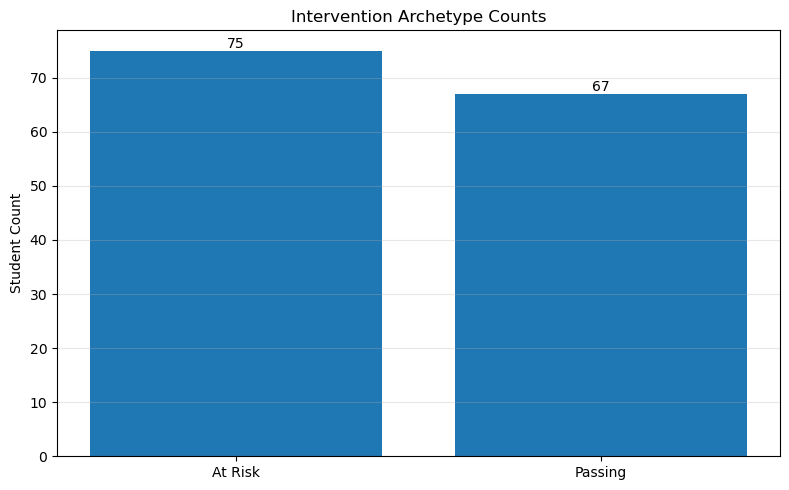

In [24]:
##########################################
##########################################
#
#    INTERVENTION ARCHETYPE COUNTS
#
##########################################
##########################################




##########################################
# Calculate
##########################################

count_df = (
    
    intervention_poc_df
    
    ["risk_flag"]
    
    .value_counts()
    
    .rename({
        
        0 : "Passing",
        1 : "At Risk"
        
    })

    .reindex([

        "At Risk",
        "Passing"
        
    ])
    
    .rename_axis("Archetype")
    
    .reset_index(name = "Count")
    
)





##########################################
# Plot
##########################################

fig, ax = plt.subplots(figsize = (8, 5))

bars = ax.bar(
    count_df["Archetype"], 
    count_df["Count"]
)

ax.bar_label(
    bars, 
    fmt = "%.0f"
)

ax.set_title("Intervention Archetype Counts")

ax.set_ylabel("Student Count")

ax.grid(
    axis = "y",
    alpha = 0.3
)

plt.tight_layout()

plt.savefig(
    "images/31_intervention_archetype_counts.png",
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()

##########################################
# Audit
##########################################

#display(count_df)

## Intervention Archetype Count Insights

Students classified as At Risk represent a slightly larger subgroup (75 students) than students classified as Passing (67 students).

The relatively comparable group sizes suggest later differences in predicted grade, classification risk, and behavioral modes reflect broad structural differences rather than isolated subgroup behavior.

## Average Archetype Predicted Grade

This analysis compares average predicted grade across intervention archetypes.

Predicted grade represents the continuous model estimate of final performance based on cumulative effort and skill information available during instruction.

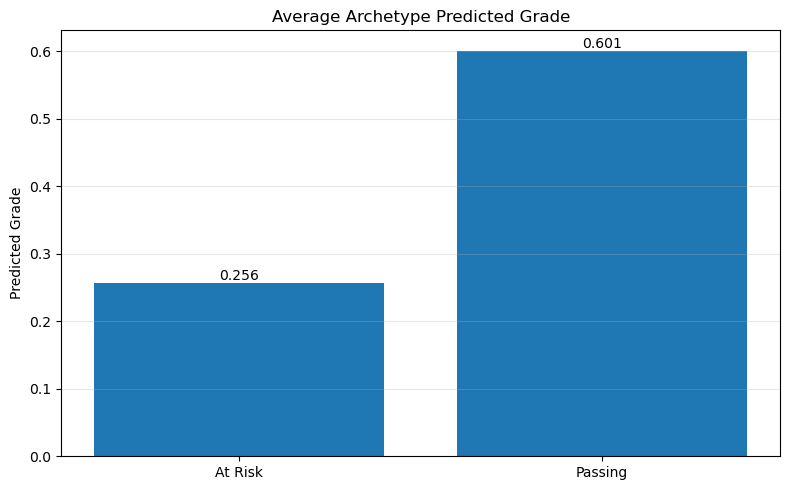

In [25]:
##########################################
##########################################
#
#    AVERAGE ARCHETYPE PREDICTED GRADE
#
##########################################
##########################################




##########################################
# Calculate
##########################################

pred_grade_df = (
    
    archetype_summary_df
    
    [["Pred Grade"]]
    
    .reset_index()
    
)

##########################################
# Plot
##########################################

fig, ax = plt.subplots(figsize = (8, 5))

bars = ax.bar(
    pred_grade_df["Archetype"], 
    pred_grade_df["Pred Grade"]
)

ax.bar_label(
    bars, 
    fmt = "%.3f"
)

ax.set_title("Average Archetype Predicted Grade")

ax.set_ylabel("Predicted Grade")

ax.grid(
    axis = "y",
    alpha = 0.3
)

plt.tight_layout()

plt.savefig(
    "images/32_intervention_archetype_pred_grade.png",
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()

##########################################
# Audit
##########################################

#display(pred_grade_df)

## Average Archetype Predicted Grade Insights

Predicted grade differs substantially across archetypes.

Students classified as At Risk maintain an average predicted grade of approximately 26%, while students classified as Passing average approximately 60%.

The separation suggests that prediction outputs may provide interpretable estimates of future performance before final outcomes are observed.

## Average Archetype Risk

This analysis compares average classification risk across intervention archetypes.

Risk values represent the estimated probability of belonging to the at-risk outcome class. 

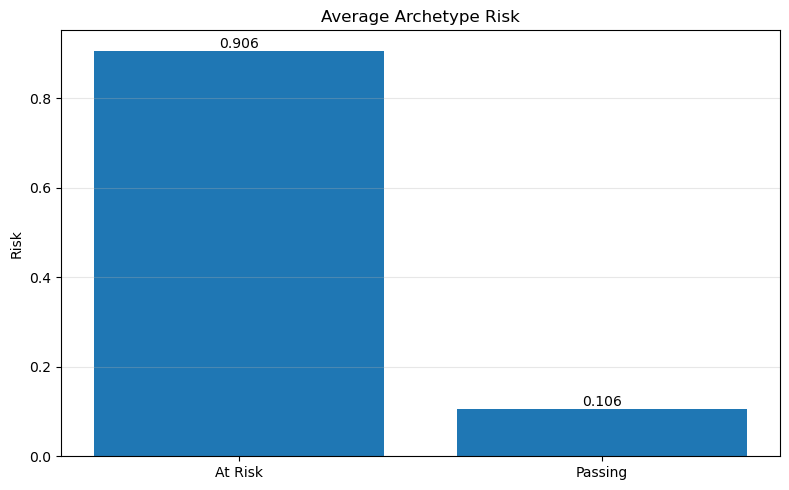

In [26]:
##########################################
##########################################
#
#       AVERAGE ARCHETYPE RISK
#
##########################################
##########################################



##########################################
# Calculate
##########################################

risk_df = (
    
    archetype_summary_df
    
    [["Risk"]]
    
    .reset_index()
    
)

##########################################
# Plot
##########################################

fig, ax = plt.subplots(figsize = (8, 5))

bars = ax.bar(
    risk_df["Archetype"], 
    risk_df["Risk"]
)

ax.bar_label(
    bars, 
    fmt = "%.3f"
)

ax.set_title("Average Archetype Risk")

ax.set_ylabel("Risk")

ax.grid(
    axis = "y",
    alpha = 0.3
)

plt.tight_layout()

plt.savefig(
    "images/33_intervention_archetype_risk.png",
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()

##########################################
# Audit
##########################################

#display(risk_df)

## Average Archetype Risk Insights

Average classification risk separates strongly across archetypes.

Students classified as At Risk exhibit substantially elevated average risk (approximately 91%), while students classified as Passing maintain relatively low average risk (approximately 11%).

This separation suggests classification outputs produce stable intervention-oriented group distinctions.

## Average Archetype Behavioral Modes

This analysis compares average behavioral mode frequencies across intervention archetypes.

Modes summarize event-level combinations of effort and skill and describe common instructional behavior patterns accumulated across instructional steps.

Behavioral modes are defined as follows:

- ZERO - no attempt submitted
- STALL - low effort / low skill
- SPAM - high effort / low skill
- COAST - low effort / high skill
- SURGE - high effort / high skill

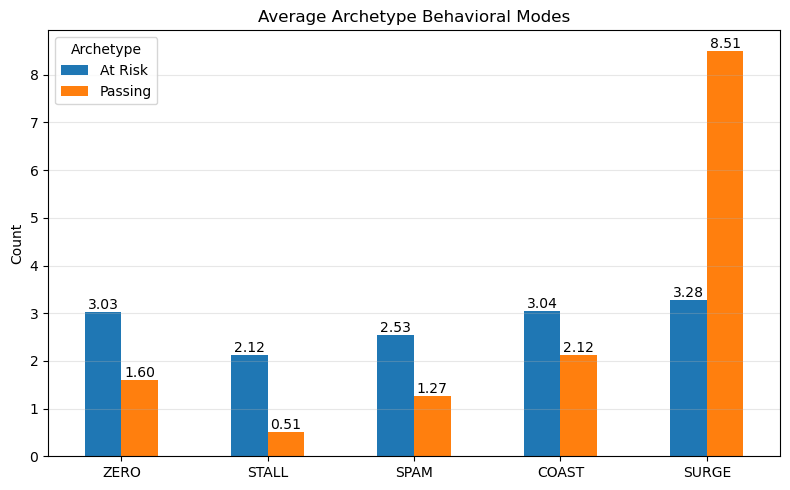

In [27]:
##########################################
##########################################
#
#   AVERAGE ARCHETYPE BEHAVIORAL MODES
#
##########################################
##########################################



##########################################
# Calculate
##########################################

mode_df = (
    
    archetype_summary_df
    
    [[

        "ZERO",
        "STALL",
        "SPAM",
        "COAST",
        "SURGE"
        
    ]]
    
   .T
    
)

##########################################
# Plot
##########################################

fig, ax = plt.subplots(figsize = (8, 5))

mode_df.plot(
    kind = "bar",
    ax = ax
)


for container in ax.containers:
    
    ax.bar_label(
        container,
        fmt = "%.2f"
    )



ax.set_title("Average Archetype Behavioral Modes")

ax.set_ylabel("Count")

ax.grid(
    axis = "y",
    alpha = 0.3
)

ax.tick_params(
    axis = "x",
    rotation = 0
)

plt.legend(
    title = "Archetype",
    loc = "upper left"
)

plt.tight_layout()

plt.savefig(
    "images/34_intervention_archetype_behavioral_modes.png",
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()

##########################################
# Audit
##########################################

#display(mode_df)

## Average Archetype Behavioral Modes Insights

Behavioral differences emerge clearly across archetypes.

Students classified as At Risk exhibit substantially lower SURGE frequency (approximately 3.3 events compared with 8.5 for Passing) and elevated frequencies across all remaining behavioral modes.

The strongest relative separation appears in STALL behavior, where students classified as At Risk exhibit approximately four times the frequency observed among students classified as Passing.

Students classified as At Risk also exhibit approximately twice the frequency of ZERO and SPAM behaviors observed among students classified as Passing, while COAST exhibits more modest separation.

These results suggest that intervention-oriented profiles reflect not only predicted outcomes, but also differences in behavioral pathways that develop throughout instruction.

## Intervention Summary

Across the intervention analyses, several patterns emerge:

- Predicted grade and classification risk produce strong and interpretable separation across archetypes.

- Intervention-oriented signal remains visible after aggregation into broad student groups.

- Behavioral mode distributions differ meaningfully between students classified as At Risk and Passing.

- Students classified as At Risk exhibit substantially lower SURGE behavior and elevated frequencies across all remaining behavioral modes, with the strongest relative separation appearing in STALL behavior.

Together, these findings suggest prediction and classification outputs may be translated into interpretable intervention profiles capable of supporting earlier instructional decisions.

## Final Summary

This project suggests that student assessment behavior contains meaningful structure that can be engineered, visualized, modeled, and translated into interpretable intervention-oriented profiles.

Across exploratory, prediction, classification, and intervention analyses:

- Effort and skill exhibit interpretable structure.

- Prediction and classification signals strengthen steadily throughout instruction.

- Signals emerge differently across performance tiers and intervention archetypes.

- Behavioral patterns provide interpretable pathways toward later outcomes.

These results support the broader idea that event-level assessment data may help inform earlier, more responsive, and more targeted instructional decision-making.

## Next Steps

Several natural extensions emerge from this work:

- Temporal signal emergence analysis across intermediate instructional targets.

- Early intervention modeling using evolving prediction and classification outputs.

- Additional temporal feature engineering and behavioral sequence analysis.

- Evaluation of nonlinear prediction and classification approaches.

- Operational dashboard development using prediction, classification, and intervention-oriented outputs to support student-level and group-level instructional monitoring.

An existing exploratory dashboard prototype developed during the exploratory analysis phase provides one possible path toward extending these ideas into interactive decision-support tools.

Exploratory Dashboard Prototype: http://www.brianspeck.com/learning_analytics

These extensions build naturally on the prediction, classification, and intervention-oriented patterns identified throughout instruction.

## Preview: Feature Influence Emergence

This exploratory visualization treats intermediate instructional states as temporary prediction targets and illustrates how feature influence evolves throughout instruction.

![Prediction Signal Emergence](images/prediction_signal_emergence_permutation_importance.gif)

## Preview: Classification Signal Emergence

This exploratory visualization treats intermediate instructional states as temporary classification targets and illustrates how classification behavior evolves throughout instruction.

![Classification Signal Emergence](images/classification_signal_emergence_confusion_counts.gif)

## Quality Assurance

Items remaining:

- Bike shedding

- Yak shaving

![Yak Shaving in a Bike Shed](images/meme.png)